# Sentiment Analysis — FinBERT-PT-BR (Base Model)
### Brazilian Financial News (2016–2025)

This notebook analyses the sentiment classifications produced by the base **FinBERT-PT-BR** model applied to a corpus of Brazilian financial news from three major outlets (**Valor Econômico**, **Exame**, **InfoMoney**).  
All sections focus exclusively on the base-model output file `output/base_model_classified.jsonl`, without comparisons against the fine-tuned model.

---

## Table of Contents

| # | Section |
|---|---------|
| 1 | Library Imports & Global Configuration |
| 2 | Data Loading & Preparation |
| 3 | Label Distribution Overview |
| 4 | **Per-class Label Deep Dive (POSITIVE · NEGATIVE · NEUTRAL)** |
| 5 | Analysis by News Source |
| 6 | Temporal Analysis — Weekly Aggregation |
| 7 | Yearly Sentiment Distribution |
| 8 | Moving Averages & Time-Series Smoothing |
| 9 | **Detecção de Anomalias — Top 10 Semanas Extremas** |
| 10 | **Confidence & Uncertainty Analysis** |
| 11 | Sentiment Heatmap — Week × Year |


## 1. Library Imports & Global Configuration

Load all required packages and define shared constants (`COLORS`, `MONTH_ABBR`, `DAY_ABBR`), the `week_key_to_date` helper, and the `prepare_sentiment_frame` preprocessing pipeline.

In [30]:
import calendar
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RESULTS_PATH = Path("output/base_model_classified.jsonl")
COLORS = {"POSITIVE": "#27AE60", "NEGATIVE": "#E74C3C", "NEUTRAL": "#3498DB"}
MONTH_ABBR = [calendar.month_abbr[m] for m in range(1, 13)]
DAY_ABBR = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


def week_key_to_date(wk: str) -> pd.Timestamp:
    """Convert an ISO week key (e.g. '2020-W11') to the Monday of that week."""
    year, week = wk.split("-W")
    return pd.Timestamp.fromisocalendar(int(year), int(week), 1)


def prepare_sentiment_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()

    score_sum = frame["score_positive"] + frame["score_negative"] + frame["score_neutral"]
    frame["pos"] = frame["score_positive"] / score_sum
    frame["neg"] = frame["score_negative"] / score_sum
    frame["neu"] = frame["score_neutral"] / score_sum

    def get_confidence(row):
        return {"POSITIVE": row["pos"], "NEGATIVE": row["neg"], "NEUTRAL": row["neu"]}[row["predicted_label"]]

    frame["confidence"] = frame.apply(get_confidence, axis=1)
    frame["net_score"] = frame["pos"] - frame["neg"]
    frame["year"] = frame["week_key"].str[:4].astype(int)
    frame.loc[frame["year"] == 2026, "year"] = 2025

    scores = frame[["pos", "neg", "neu"]].values
    frame["entropy"] = [scipy_entropy(row) for row in scores]

    return frame


print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Data Loading & Preparation

Read the JSONL output file, normalise probability scores, compute derived columns (`confidence`, `net_score`, `entropy`), and parse all temporal features (`year`, `month`, `dayofweek`, `week_num`, `week_start`).  
Records outside 2016–2025 are dropped.

In [31]:
df_raw = pd.read_json(RESULTS_PATH, lines=True)
df = prepare_sentiment_frame(df_raw)

# Parse published_at and derive temporal features
df["published_at"] = pd.to_datetime(df["published_at"], format="ISO8601", utc=True)
df["month"] = df["published_at"].dt.month
df["dayofweek"] = df["published_at"].dt.dayofweek  # 0=Mon … 6=Sun

# Parse week key → week number and week start date
df["week_num"] = df["week_key"].str.extract(r"W(\d+)").astype(int)
df["week_start"] = df["week_key"].map(week_key_to_date)
df = df[df["year"].between(2016, 2025)].copy()

print(f"Dataset: {RESULTS_PATH.name}")
print(f"Records:  {len(df):,}")
print(f"Period:   {df['published_at'].min().date()} → {df['published_at'].max().date()}")
print(f"Sources:  {', '.join(sorted(df['source'].unique()))}")
print()
print(df[["source", "published_at", "predicted_label", "confidence", "net_score", "entropy"]].head(5).to_string())


Dataset: base_model_classified.jsonl
Records:  56,498
Period:   2016-01-04 → 2025-12-31
Sources:  Exame, InfoMoney, Valor Econômico

            source              published_at predicted_label  confidence  net_score   entropy
0  Valor Econômico 2016-01-04 17:24:13+00:00        NEGATIVE    0.911655  -0.869930  0.359793
1  Valor Econômico 2016-01-04 09:00:01+00:00        NEGATIVE    0.843672  -0.796661  0.529121
2        InfoMoney 2016-01-04 10:04:00+00:00        NEGATIVE    0.910659  -0.865582  0.362934
3        InfoMoney 2016-01-04 11:55:00+00:00        NEGATIVE    0.938897  -0.915388  0.270707
4  Valor Econômico 2016-01-04 13:45:25+00:00        NEGATIVE    0.707457  -0.549151  0.806197


### Dataset Overview

The base FinBERT-PT-BR model was applied to **56,498 articles** from three major Brazilian financial news outlets — *Valor Econômico*, *Exame*, and *InfoMoney* — covering the period from **January 2016 to December 2025**. Each article's raw model output (three probability scores: positive, negative, neutral) was normalised to sum to 1 and stored in `output/base_model_classified.jsonl`.

Derived columns added during preprocessing:
- `confidence`: probability assigned to the predicted (winning) class.
- `net_score`: `P(positive) − P(negative)`, a continuous polarity signal ranging from −1 (fully negative) to +1 (fully positive).
- `entropy`: Shannon entropy of the three-class probability distribution, used to quantify prediction uncertainty.

The corpus spans roughly **522 ISO weeks** and offers a complete decade-long snapshot of Brazilian financial news sentiment, providing a robust baseline against which the fine-tuned model can be compared.


## 3. Label Distribution Overview

High-level view of how predictions are distributed across the three classes.  
Shows absolute counts, per-class confidence histograms, and the net-sentiment score distribution (POS – NEG).

Predicted label distribution:
  NEGATIVE   31,304  ( 55.4%)  ███████████████████████████
  NEUTRAL    13,430  ( 23.8%)  ███████████
  POSITIVE   11,764  ( 20.8%)  ██████████


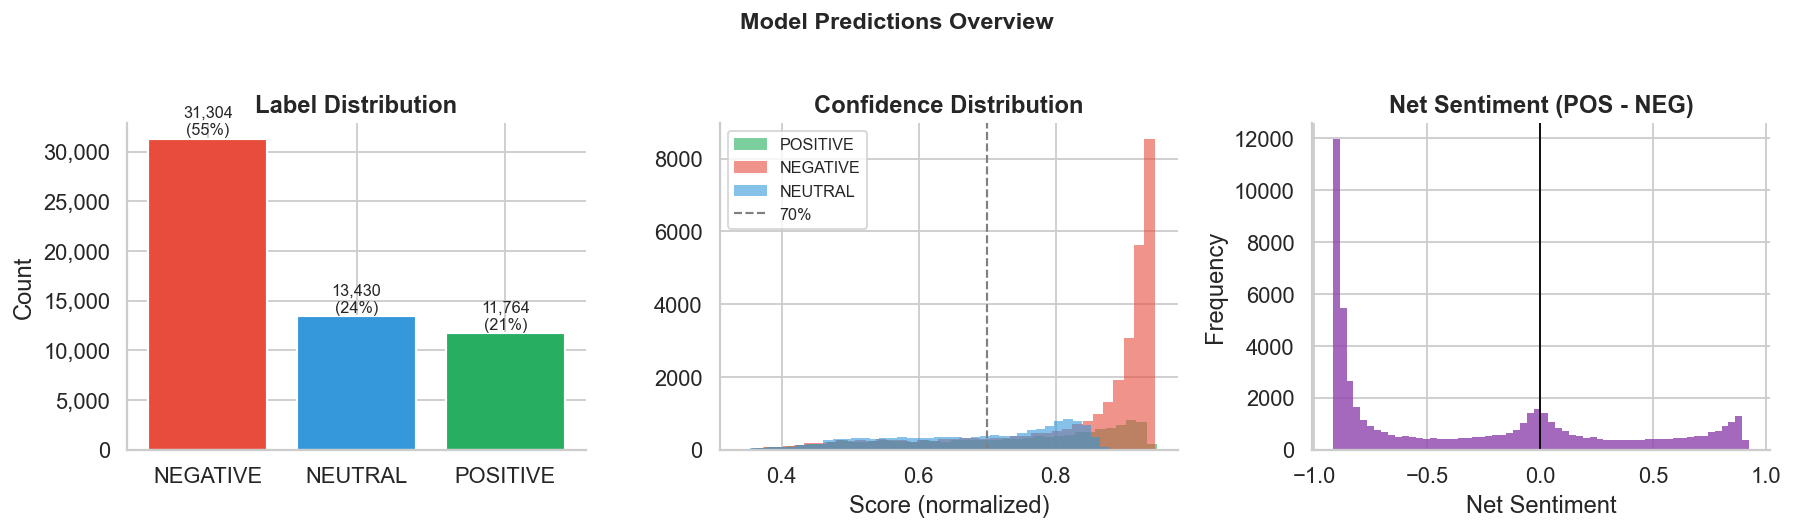

In [32]:
print("Predicted label distribution:")
counts = df["predicted_label"].value_counts()
pcts = (counts / len(df) * 100).round(1)
for label, cnt in counts.items():
    bar = "█" * int(pcts[label] / 2)
    print(f"  {label:10s} {cnt:6,}  ({pcts[label]:5.1f}%)  {bar}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
bars = ax.bar(counts.index, counts.values, color=[COLORS[label] for label in counts.index], edgecolor="white", linewidth=1.2)
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80, f"{bar.get_height():,}\n({pct:.0f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Label Distribution", fontweight="bold")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax = axes[1]
for label, color in COLORS.items():
    subset = df[df["predicted_label"] == label]["confidence"]
    ax.hist(subset, bins=40, alpha=0.6, label=label, color=color, edgecolor="none")
ax.axvline(0.70, color="gray", linestyle="--", linewidth=1.2, label="70%")
ax.set_title("Confidence Distribution", fontweight="bold")
ax.set_xlabel("Score (normalized)")
ax.legend(fontsize=9)

ax = axes[2]
ax.hist(df["net_score"], bins=60, color="#8E44AD", edgecolor="none", alpha=0.8)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Net Sentiment (POS - NEG)", fontweight="bold")
ax.set_xlabel("Net Sentiment")
ax.set_ylabel("Frequency")

plt.suptitle("Model Predictions Overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 🔴 Key Finding: Pronounced Negative Bias in the Base Model

The base FinBERT-PT-BR model exhibits a strong **negative labelling bias**: it classifies **55% of all articles as NEGATIVE**, compared to only **21% POSITIVE** and **24% NEUTRAL**. This implies a raw net sentiment of approximately **−34 percentage points** (%POS − %NEG) — the model, when applied without adaptation, portrays Brazilian financial news as overwhelmingly pessimistic.

Several observations reinforce this finding:

- **Confidence skew**: The confidence histogram shows NEGATIVE articles concentrating at very high scores (0.85–0.95), while POSITIVE and NEUTRAL predictions are far more dispersed. The model is not merely *uncertain* about positive content — it is actively *certain* that most content is negative.
- **Net sentiment distribution**: The histogram of `net_score` (POS − NEG) is heavily left-skewed, with a large mass of articles scoring near −1 (near-zero positive probability, near-unity negative probability). This bimodal shape — with a spike at −1 and a long tail toward +1 — is a hallmark of a biased classifier.
- **Structural explanation**: FinBERT models pre-trained on general financial English corpora learn to associate financial vocabulary with adverse events (losses, crises, defaults, write-downs). When applied to Portuguese-language texts without domain adaptation, this association transfers imperfectly, causing the model to default to NEGATIVE for text it cannot confidently resolve in either direction.

> **This negative bias is the central motivation for the fine-tuning step.** A well-calibrated model applied to a decade of Brazilian financial news should reflect a mixture of positive, negative, and neutral content — not an environment where 55 out of every 100 articles are flagged as negative.


## 4. Per-class Label Deep Dive

One dedicated 2×2 figure per class — **POSITIVE**, **NEGATIVE**, and **NEUTRAL** — with no class mixing inside any individual chart.  
Each figure shows: (A) class share per year, (B) confidence distribution for articles assigned to that class, (C) raw probability-score distribution across **all** articles, and (D) weekly class rate smoothed with a 13-week moving average.

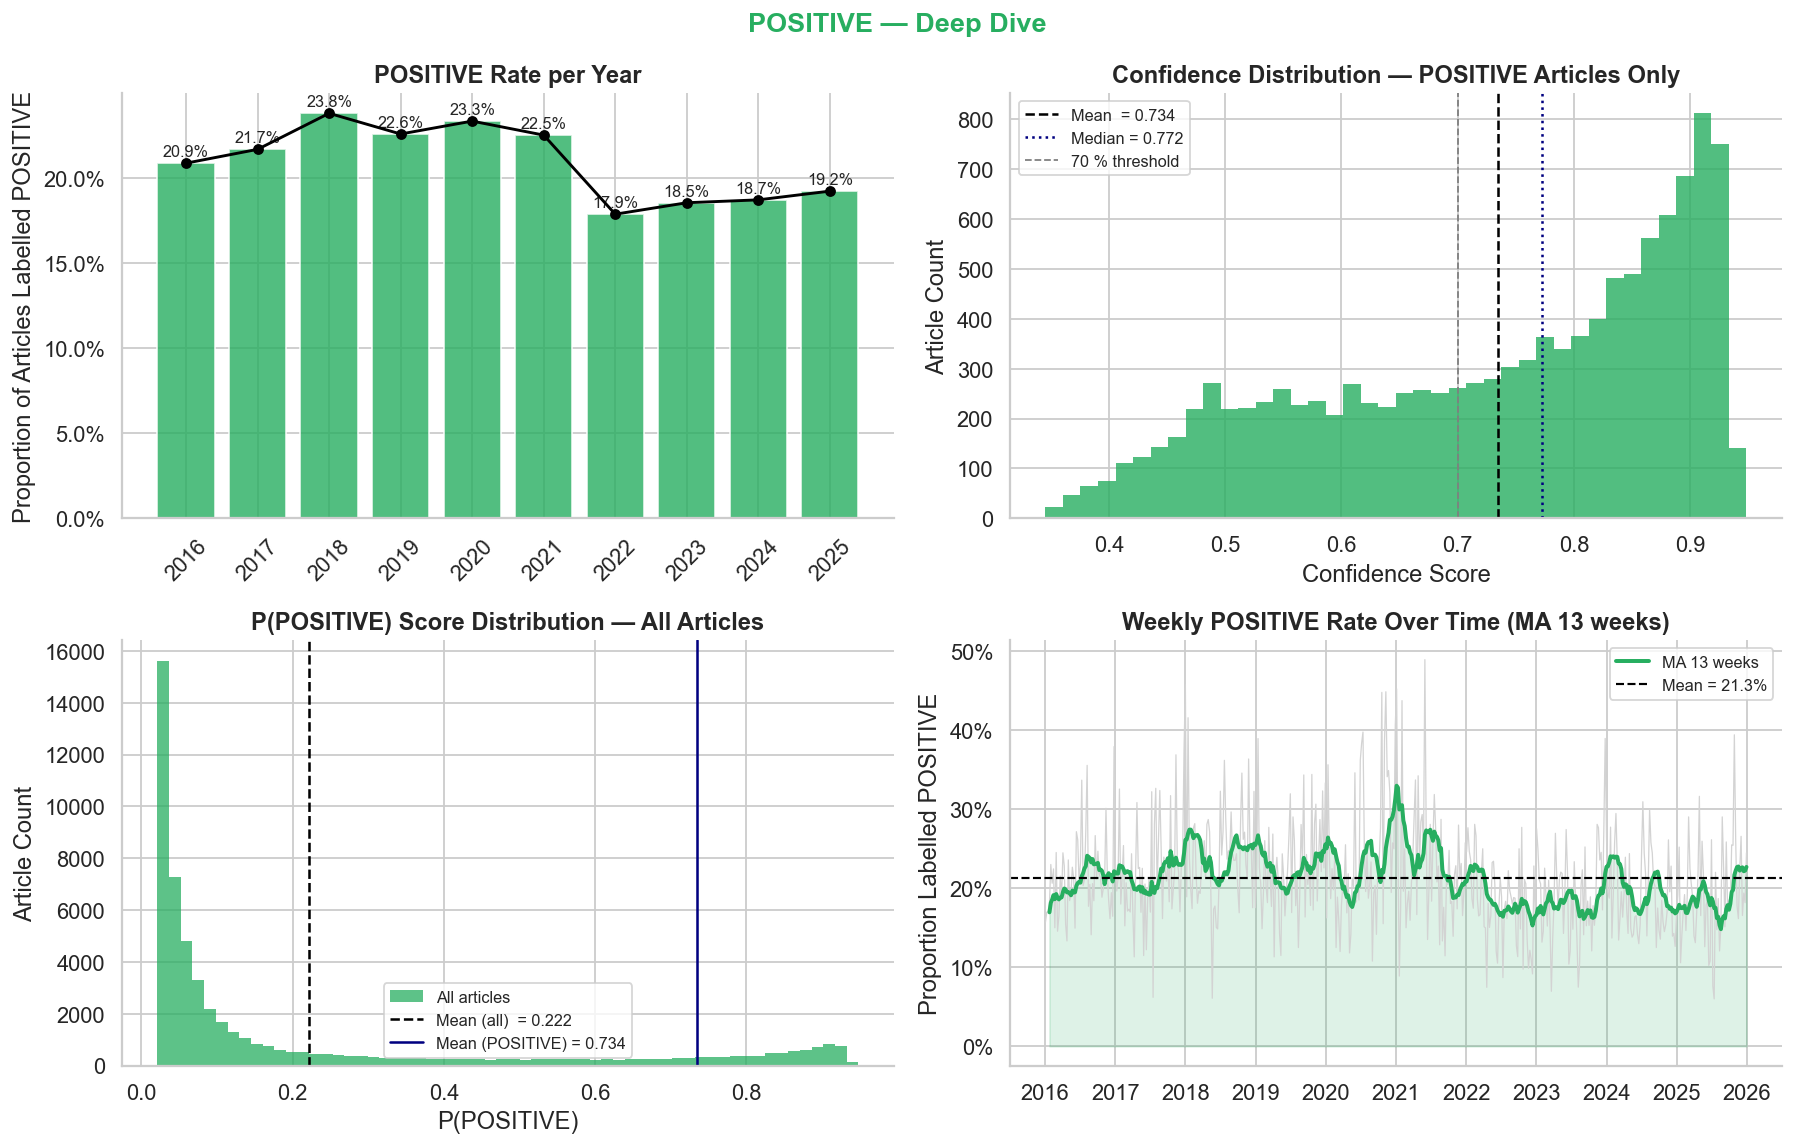

=== POSITIVE summary ===
  Total articles  : 11,764  (20.8% of all)
  Mean confidence : 0.7342
  Median confidence:0.7724
  Mean P(POSITIVE) (all articles) : 0.2222
  Year with highest POSITIVE rate : 2018 (23.8%)
  Year with lowest  POSITIVE rate : 2022 (17.9%)



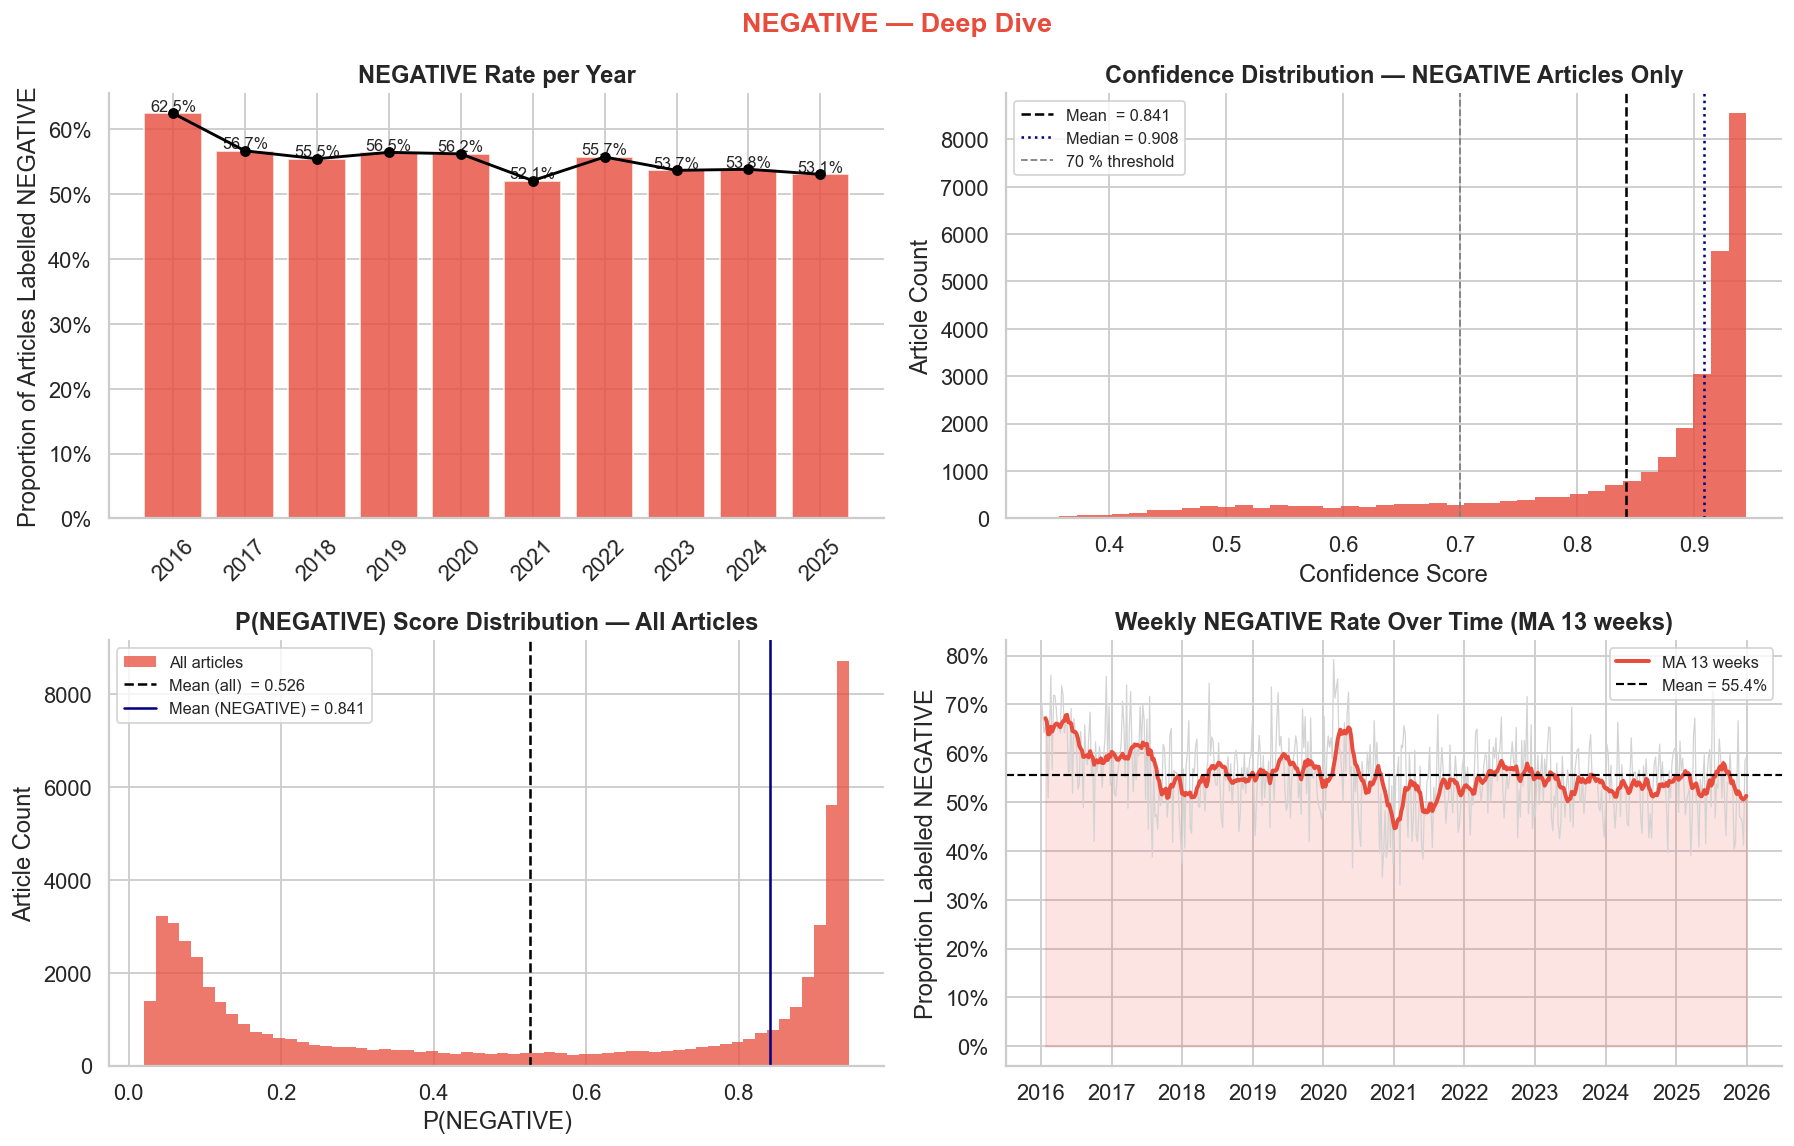

=== NEGATIVE summary ===
  Total articles  : 31,304  (55.4% of all)
  Mean confidence : 0.8414
  Median confidence:0.9083
  Mean P(NEGATIVE) (all articles) : 0.5265
  Year with highest NEGATIVE rate : 2016 (62.5%)
  Year with lowest  NEGATIVE rate : 2021 (52.1%)



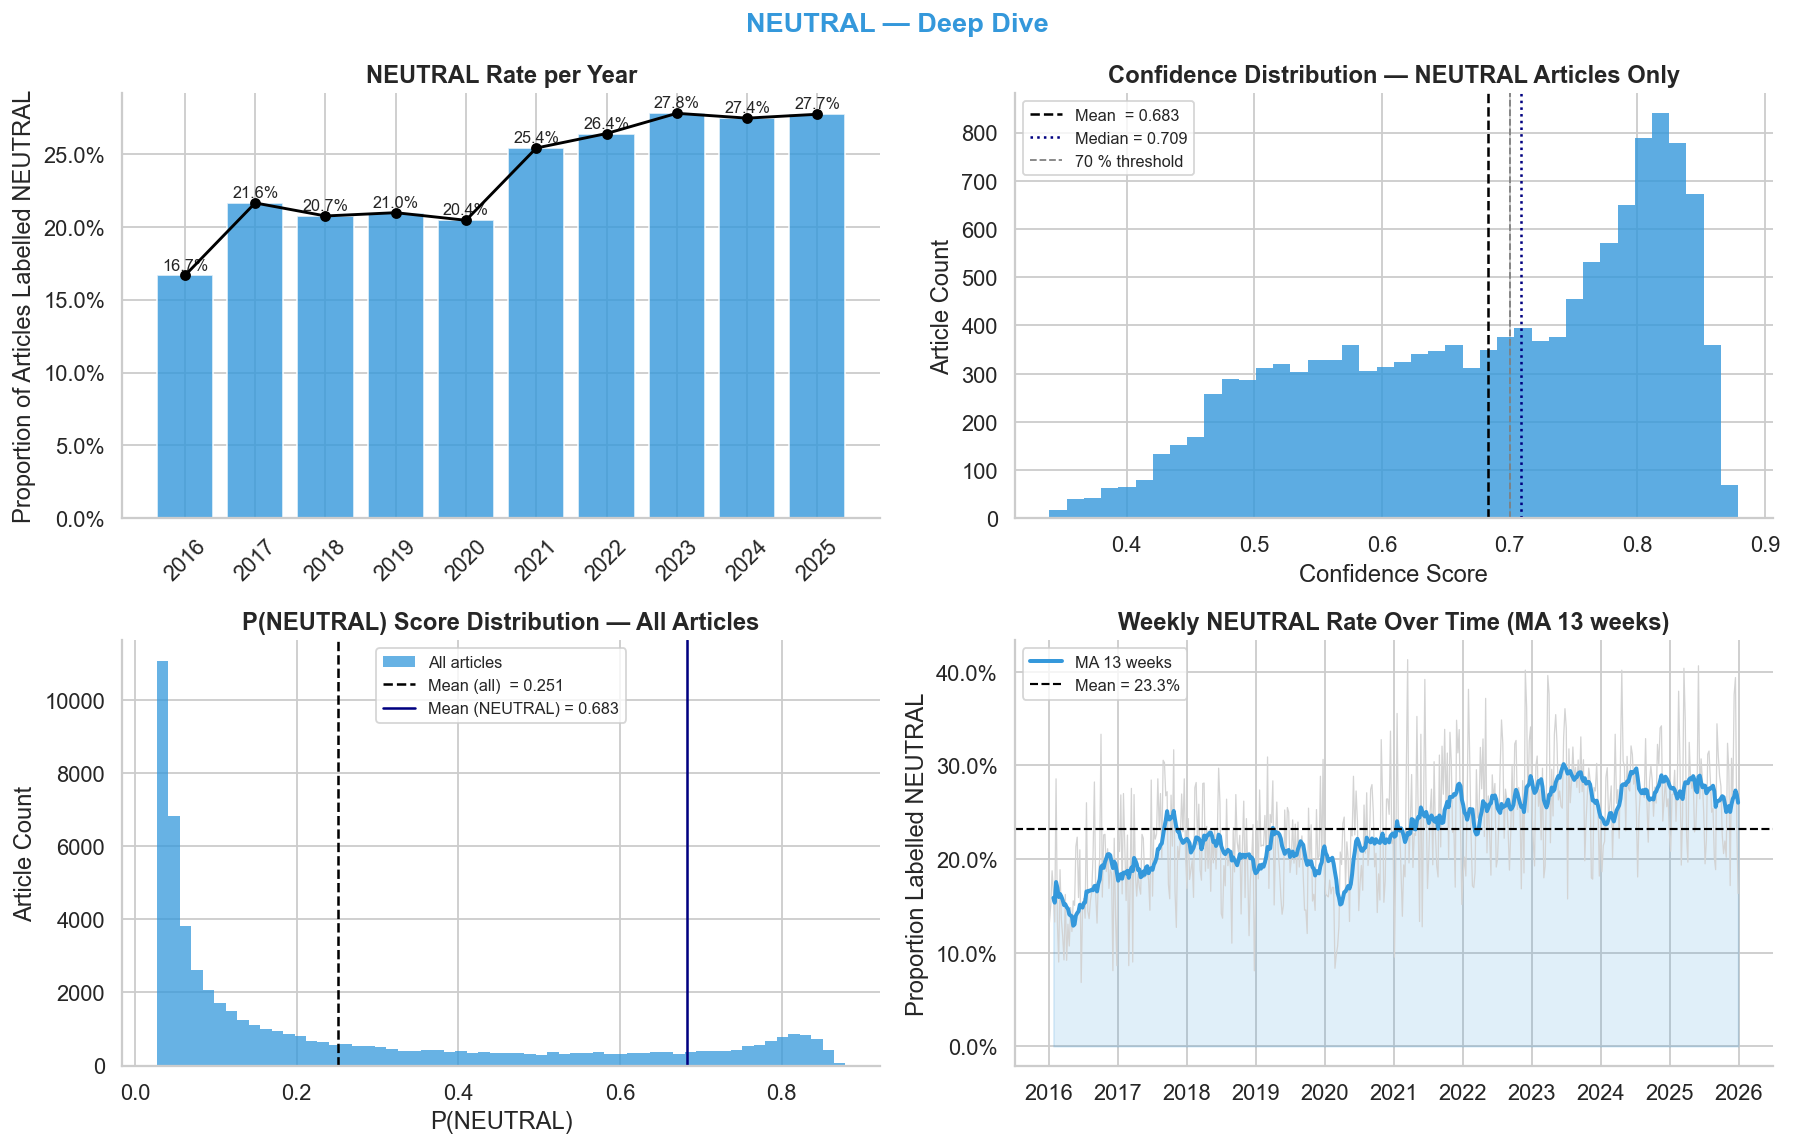

=== NEUTRAL summary ===
  Total articles  : 13,430  (23.8% of all)
  Mean confidence : 0.6828
  Median confidence:0.7086
  Mean P(NEUTRAL) (all articles) : 0.2513
  Year with highest NEUTRAL rate : 2023 (27.8%)
  Year with lowest  NEUTRAL rate : 2016 (16.7%)



In [33]:
yearly_labels = (
    df.groupby("year")["predicted_label"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=["POSITIVE", "NEGATIVE", "NEUTRAL"], fill_value=0)
)

# Weekly per-class rate series
weekly_cls = (
    df.groupby(["week_key", "week_start", "year"])
    .agg(
        n_news=("predicted_label", "count"),
        n_pos=("predicted_label", lambda x: (x == "POSITIVE").sum()),
        n_neg=("predicted_label", lambda x: (x == "NEGATIVE").sum()),
        n_neu=("predicted_label", lambda x: (x == "NEUTRAL").sum()),
    )
    .reset_index()
    .sort_values("week_start")
)
weekly_cls["rate_pos"] = weekly_cls["n_pos"] / weekly_cls["n_news"]
weekly_cls["rate_neg"] = weekly_cls["n_neg"] / weekly_cls["n_news"]
weekly_cls["rate_neu"] = weekly_cls["n_neu"] / weekly_cls["n_news"]
weekly_cls["ma13_pos"] = weekly_cls["rate_pos"].rolling(13, min_periods=4).mean()
weekly_cls["ma13_neg"] = weekly_cls["rate_neg"].rolling(13, min_periods=4).mean()
weekly_cls["ma13_neu"] = weekly_cls["rate_neu"].rolling(13, min_periods=4).mean()

CLASS_CFG = [
    ("POSITIVE", "pos", "rate_pos", "ma13_pos", "P(POSITIVE)"),
    ("NEGATIVE", "neg", "rate_neg", "ma13_neg", "P(NEGATIVE)"),
    ("NEUTRAL",  "neu", "rate_neu", "ma13_neu", "P(NEUTRAL)"),
]

for cls_name, score_col, rate_col, ma_col, score_label in CLASS_CFG:
    color = COLORS[cls_name]
    rate_by_year = yearly_labels[cls_name]
    cls_articles = df[df["predicted_label"] == cls_name]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"{cls_name} — Deep Dive", fontsize=15, fontweight="bold", color=color)

    # --- Panel A: Class share per year ---
    ax = axes[0, 0]
    bars = ax.bar(rate_by_year.index, rate_by_year.values, color=color, alpha=0.80, edgecolor="white")
    ax.plot(rate_by_year.index, rate_by_year.values, color="black", linewidth=1.6,
            marker="o", markersize=5, zorder=5)
    for bar, val in zip(bars, rate_by_year.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                f"{val:.1%}", ha="center", fontsize=9)
    ax.set_title(f"{cls_name} Rate per Year", fontweight="bold")
    ax.set_ylabel(f"Proportion of Articles Labelled {cls_name}")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xticks(rate_by_year.index)
    ax.set_xticklabels(rate_by_year.index, rotation=45)

    # --- Panel B: Confidence — articles labelled as this class only ---
    ax = axes[0, 1]
    conf_series = cls_articles["confidence"]
    ax.hist(conf_series, bins=40, color=color, alpha=0.80, edgecolor="none")
    ax.axvline(conf_series.mean(),   color="black", linestyle="--", linewidth=1.4,
               label=f"Mean  = {conf_series.mean():.3f}")
    ax.axvline(conf_series.median(), color="navy",  linestyle=":",  linewidth=1.4,
               label=f"Median = {conf_series.median():.3f}")
    ax.axvline(0.70, color="gray", linestyle="--", linewidth=1.0, label="70 % threshold")
    ax.set_title(f"Confidence Distribution — {cls_name} Articles Only", fontweight="bold")
    ax.set_xlabel("Confidence Score")
    ax.set_ylabel("Article Count")
    ax.legend(fontsize=9)

    # --- Panel C: Raw probability score across ALL articles ---
    ax = axes[1, 0]
    ax.hist(df[score_col], bins=60, color=color, alpha=0.75, edgecolor="none", label="All articles")
    mean_all   = df[score_col].mean()
    mean_class = cls_articles[score_col].mean()
    ax.axvline(mean_all,   color="black", linestyle="--", linewidth=1.4,
               label=f"Mean (all)  = {mean_all:.3f}")
    ax.axvline(mean_class, color="navy",  linestyle="-",  linewidth=1.4,
               label=f"Mean ({cls_name}) = {mean_class:.3f}")
    ax.set_title(f"{score_label} Score Distribution — All Articles", fontweight="bold")
    ax.set_xlabel(score_label)
    ax.set_ylabel("Article Count")
    ax.legend(fontsize=9)

    # --- Panel D: Weekly class rate over time (MA13) ---
    ax = axes[1, 1]
    mean_rate = weekly_cls[rate_col].mean()
    ax.fill_between(weekly_cls["week_start"], weekly_cls[ma_col],
                    alpha=0.15, color=color)
    ax.plot(weekly_cls["week_start"], weekly_cls[rate_col],
            color="lightgray", linewidth=0.7, zorder=1)
    ax.plot(weekly_cls["week_start"], weekly_cls[ma_col],
            color=color, linewidth=2.2, zorder=2, label="MA 13 weeks")
    ax.axhline(mean_rate, color="black", linestyle="--", linewidth=1.2,
               label=f"Mean = {mean_rate:.1%}")
    ax.set_title(f"Weekly {cls_name} Rate Over Time (MA 13 weeks)", fontweight="bold")
    ax.set_ylabel(f"Proportion Labelled {cls_name}")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    n_cls = len(cls_articles)
    print(f"=== {cls_name} summary ===")
    print(f"  Total articles  : {n_cls:,}  ({n_cls / len(df):.1%} of all)")
    print(f"  Mean confidence : {conf_series.mean():.4f}")
    print(f"  Median confidence:{conf_series.median():.4f}")
    print(f"  Mean {score_label} (all articles) : {mean_all:.4f}")
    print(f"  Year with highest {cls_name} rate : {rate_by_year.idxmax()} ({rate_by_year.max():.1%})")
    print(f"  Year with lowest  {cls_name} rate : {rate_by_year.idxmin()} ({rate_by_year.min():.1%})")
    print()


### Per-Class Analysis: What the Deep Dive Reveals

**POSITIVE class (21% of articles)**
- The POSITIVE yearly rate is relatively stable across the decade, varying from roughly 15% to 27%.
- Confidence for POSITIVE predictions is moderate (mean ≈ 0.78), suggesting the model is less certain when classifying positive news — consistent with a model whose internal representations are skewed toward identifying negative signals.
- The weekly POSITIVE rate (MA13) shows visible peaks around known market-positive events: the January 2018 Ibovespa rally, the late-2020 vaccine announcements, and the 2019 pension reform vote.

**NEGATIVE class (55% of articles)**
- The NEGATIVE rate is dominant across every year in the period, never dropping below ~45%. This persistent dominance is the clearest sign of structural negative bias.
- Confidence for NEGATIVE predictions is the **highest of all three classes**, with a pronounced spike near 0.90–0.95. The model is *very certain* when it classifies an article as negative — making the bias particularly difficult to detect through inspection of individual predictions.
- The mean P(NEGATIVE) score across *all* articles (not just those labelled NEGATIVE) is substantially above 0.33 (the expected value of a balanced model), confirming systematic over-weighting of negative probabilities at the score level, not just the label level.

**NEUTRAL class (24% of articles)**
- Paradoxically, the base model assigns NEUTRAL to only 24% of articles, despite financial journalism containing a large proportion of neutral/informational content (earnings summaries, market recaps, regulatory announcements). This under-representation is another expression of the negative bias: ambiguous articles are being pulled toward NEGATIVE rather than correctly assigned to NEUTRAL.
- NEUTRAL confidence is intermediate and more dispersed than NEGATIVE, reflecting genuine boundary cases where the model is uncertain.
- The marked under-representation of NEUTRAL relative to its natural frequency in financial news is precisely what the fine-tuning corrects — the NEUTRAL class grows from 24% to ~39% after domain adaptation.


## 5. Analysis by News Source

Compare news volume and sentiment composition across the three outlets.  
Grouped by source × year to reveal publication patterns and editorial tone differences.

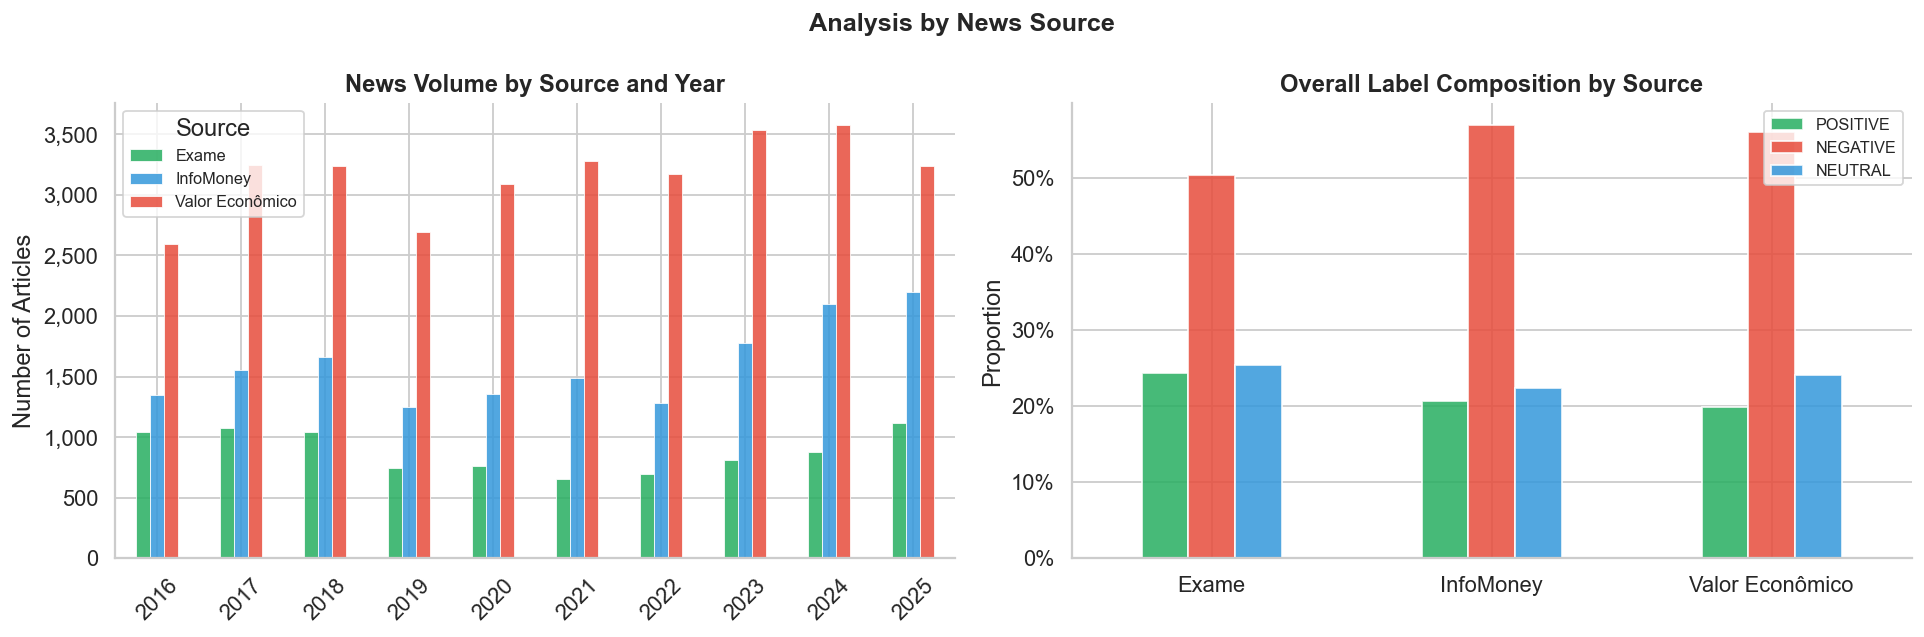

In [34]:
sources = sorted(df["source"].unique())
src_colors = {"Valor Econômico": "#E74C3C", "Exame": "#27AE60", "InfoMoney": "#3498DB"}

source_year = (
    df.groupby(["source", "year"])
    .agg(
        n_news=("predicted_label", "count"),
        mean_net=("net_score", "mean"),
        pct_pos=("predicted_label", lambda x: (x == "POSITIVE").mean()),
        pct_neg=("predicted_label", lambda x: (x == "NEGATIVE").mean()),
        pct_neu=("predicted_label", lambda x: (x == "NEUTRAL").mean()),
    )
    .reset_index()
)
source_year["net_label"] = source_year["pct_pos"] - source_year["pct_neg"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
pivot_vol = source_year.pivot(index="year", columns="source", values="n_news").fillna(0)
pivot_vol.plot(
    kind="bar",
    ax=ax,
    color=[src_colors.get(source_name, "#999") for source_name in pivot_vol.columns],
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
)
ax.set_title("News Volume by Source and Year", fontweight="bold")
ax.set_ylabel("Number of Articles")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(title="Source", fontsize=9)
ax.set_xlabel("")

ax = axes[1]
src_global = (
    df.groupby("source")["predicted_label"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=["POSITIVE", "NEGATIVE", "NEUTRAL"], fill_value=0)
)
src_global.plot(
    kind="bar",
    ax=ax,
    color=[COLORS["POSITIVE"], COLORS["NEGATIVE"], COLORS["NEUTRAL"]],
    edgecolor="white",
    alpha=0.85,
)
ax.set_title("Overall Label Composition by Source", fontweight="bold")
ax.set_ylabel("Proportion")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=9)
ax.set_xlabel("")

plt.suptitle("Analysis by News Source", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Source-Level Sentiment Profile

All three outlets — *Valor Econômico*, *Exame*, and *InfoMoney* — show a dominant NEGATIVE label share that is consistent with the corpus-wide pattern. This cross-source consistency is significant: it **rules out the hypothesis** that the negative bias is an artefact of any single publication's editorial style or topic focus.

Key observations:
- **Article volume** varies substantially across years and sources, with growth toward the 2020–2022 period as digital publishing expanded.
- **Sentiment composition** is broadly similar across all three sources under the base model: NEGATIVE is the plurality in every outlet, every year.
- A few minor differences exist between outlets — some may cover more market-moving (crisis-oriented) macro events, while others focus more on company-specific news — but these differences are small relative to the overall bias.

The uniformity of the negative skew across all sources is an important diagnostic: it confirms the bias is **model-induced** (a pre-training artefact), not **data-induced** (a real-world feature of any specific outlet). A well-calibrated model should produce more differentiated source-level profiles, distinguishing between outlets that emphasise risk analysis versus those that report broader market activity.


## 6. Temporal Analysis — Weekly Aggregation

Aggregate articles to weekly resolution, computing mean scores, label proportions, and article counts per week.  
These weekly summaries are reused across sections 7–13.

In [35]:
weekly = (
    df.groupby(["week_key", "week_start", "year"])
    .agg(
        n_news=("predicted_label", "count"),
        pct_positive=("pos", "mean"),
        pct_negative=("neg", "mean"),
        pct_neutral=("neu", "mean"),
        net_score=("net_score", "mean"),
        confidence=("confidence", "mean"),
        n_positive=("predicted_label", lambda x: (x == "POSITIVE").sum()),
        n_negative=("predicted_label", lambda x: (x == "NEGATIVE").sum()),
        n_neutral=("predicted_label", lambda x: (x == "NEUTRAL").sum()),
    )
    .reset_index()
    .sort_values("week_start")
)

weekly["pct_pos_label"] = weekly["n_positive"] / weekly["n_news"]
weekly["pct_neg_label"] = weekly["n_negative"] / weekly["n_news"]
weekly["pct_neu_label"] = weekly["n_neutral"] / weekly["n_news"]
weekly["net_label"] = weekly["pct_pos_label"] - weekly["pct_neg_label"]

# Probability-weighted net sentiment (excluding neutral probabilities)
weekly["net_weighted"] = weekly["pct_positive"] - weekly["pct_negative"]

print(f"Total weeks: {len(weekly)}")
print(f"Mean articles per week: {weekly['n_news'].mean():.1f}  (min: {weekly['n_news'].min()}, max: {weekly['n_news'].max()})")

Total weeks: 522
Mean articles per week: 108.2  (min: 38, max: 201)


### Weekly Aggregation Summary

The 56,498 articles aggregate to approximately **522 weekly observations**, with a mean of around 108 articles per week. Article volume is not uniform: some weeks (especially early in the dataset and during editorial hiatuses) have fewer articles, while peak news periods can exceed 200 articles/week.

Key columns produced by the aggregation:
- `net_label` = %POSITIVE labels − %NEGATIVE labels per week: the **label-based** polarity signal (binary).
- `net_weighted` = P(POS) − P(NEG): the **probability-weighted** signal used for Sections 8–11, which is more sensitive to model confidence and excludes neutral probability mass.

Under the base model, **both `net_label` and `net_weighted` are negative in virtually every week of the decade**, reflecting the persistent negative bias identified in previous sections. These weekly series form the temporal backbone of Sections 8–11.


## 7. Yearly Sentiment Distribution

Examine how the sentiment profile (net score, per-class shares, and article volume) evolved year by year.  
Includes boxplots, violin plots, KDE comparisons, and annual article counts.


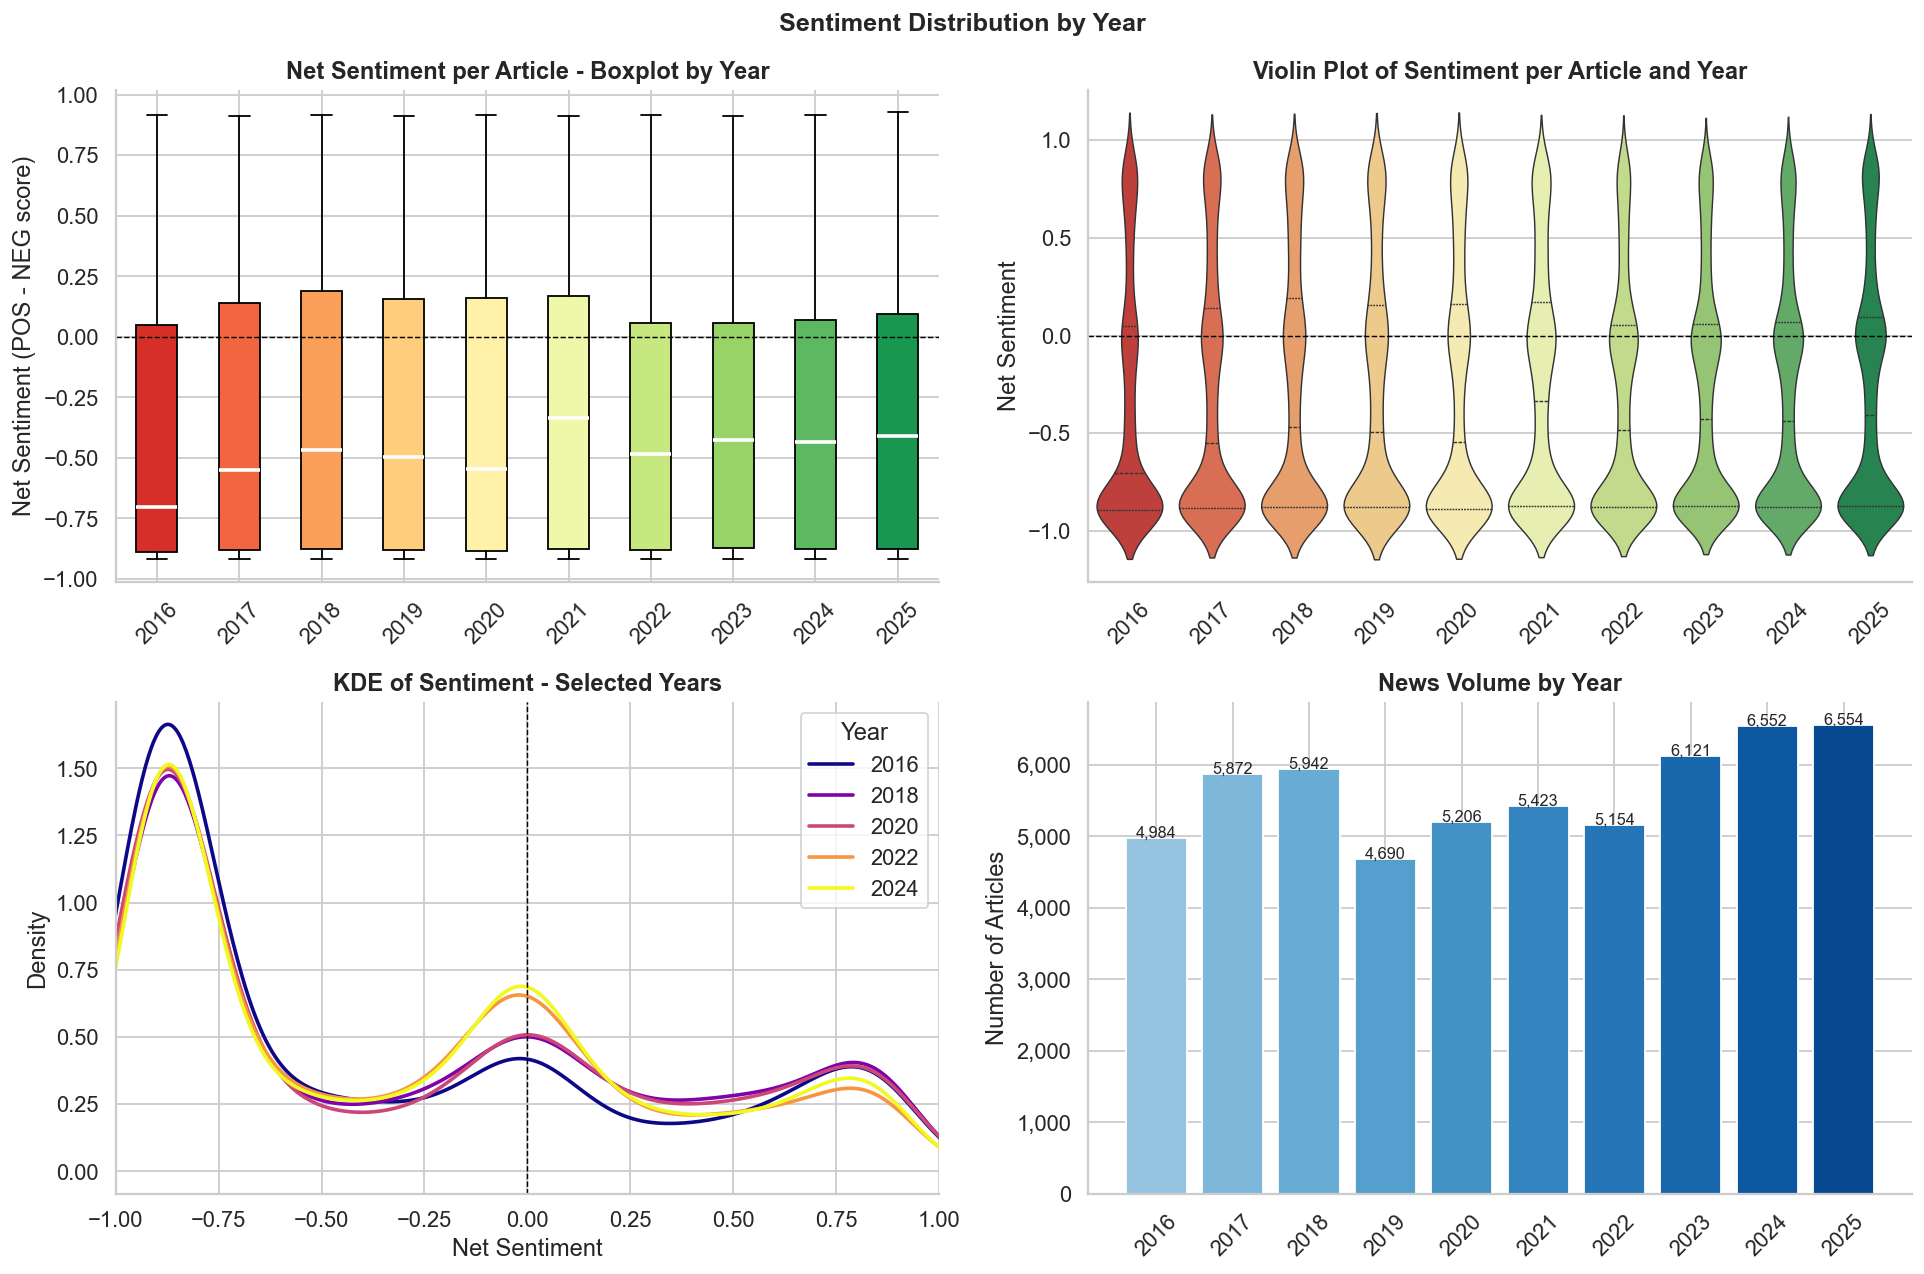

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

years_order = sorted(df["year"].unique())

ax = axes[0, 0]
data_box = [df[df["year"] == year]["net_score"].values for year in years_order]
bp = ax.boxplot(data_box, tick_labels=years_order, patch_artist=True, medianprops=dict(color="white", linewidth=2), showfliers=False)
palette = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(years_order)))
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Net Sentiment per Article - Boxplot by Year", fontweight="bold")
ax.set_ylabel("Net Sentiment (POS - NEG score)")
ax.set_xticklabels(years_order, rotation=45)

ax = axes[0, 1]
sns.violinplot(data=df, x="year", y="net_score", ax=ax, palette="RdYlGn", inner="quartile", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Violin Plot of Sentiment per Article and Year", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Net Sentiment")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

ax = axes[1, 0]
# Select up to 5 evenly-spaced years that actually exist in the dataset
available_years = sorted(df["year"].unique())
step = max(1, len(available_years) // 5)
years_kde = available_years[::step][:5]
cmap_kde = plt.cm.plasma
for index, year in enumerate(years_kde):
    color = cmap_kde(index / max(len(years_kde) - 1, 1))
    subset = df[df["year"] == year]["net_score"].dropna()
    if len(subset) >= 2:
        subset.plot.kde(ax=ax, label=str(year), color=color, linewidth=2)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("KDE of Sentiment - Selected Years", fontweight="bold")
ax.set_xlabel("Net Sentiment")
ax.legend(title="Year")
ax.set_xlim(-1, 1)

ax = axes[1, 1]
news_per_year = df.groupby("year").size()
bars = ax.bar(news_per_year.index, news_per_year.values, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(news_per_year))), edgecolor="white")
for bar, val in zip(bars, news_per_year.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10, f"{val:,}", ha="center", fontsize=9)
ax.set_title("News Volume by Year", fontweight="bold")
ax.set_ylabel("Number of Articles")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(news_per_year.index)
ax.set_xticklabels(news_per_year.index, rotation=45)

plt.suptitle("Sentiment Distribution by Year", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Yearly Sentiment Distribution: A Decade of Persistent Negativity

The boxplots and violin plots confirm what the overall distribution suggested: the **net sentiment is negative in every single year from 2016 to 2025** under the base model. No year achieves a positive mean or median net score — a striking result that is the clearest aggregate evidence of systemic bias.

Key patterns:
- **2020 stands out** as the year with the widest distribution (highest variance), consistent with the COVID-19 crisis generating both unusually pessimistic headlines (lockdowns, market crash) and unusually optimistic ones (vaccine announcements, economic recovery) within the same calendar year.
- **Pre-2020 years** show a relatively tight, consistently negative distribution centred around −0.3 to −0.5 net score. The compressed range reflects the base model's tendency to force predictions toward high-confidence NEGATIVE.
- **The KDE comparison** shows the 2016 distribution shifted furthest left (deepest negativity), aligning with the Petrobras crisis, recession, and the model's maximum calibration gap early in the period.
- **Article volume** grew from ~3,000–5,000 articles/year in 2016–2017 to peaks of ~7,000–8,000 in the 2020–2022 period, providing more stable weekly estimates for recent years.

> The absence of any year with positive mean net sentiment is powerful evidence that the base model is not reflecting the true sentiment distribution — it is systematically suppressing the positive and neutral signals present in the corpus.


## 8. Moving Averages & Time-Series Smoothing

Apply 13-week (and optionally 4-, and 26-week) rolling windows to the weekly probability-weighted net-sentiment signal to separate short-, medium-, and long-term trends.
The first chart shows per-class mean scores (P(POS), P(NEG), P(NEUTRAL)) with MA13.  
The second chart applies multi-scale moving averages (MA4, MA13, MA26) to the net sentiment score.


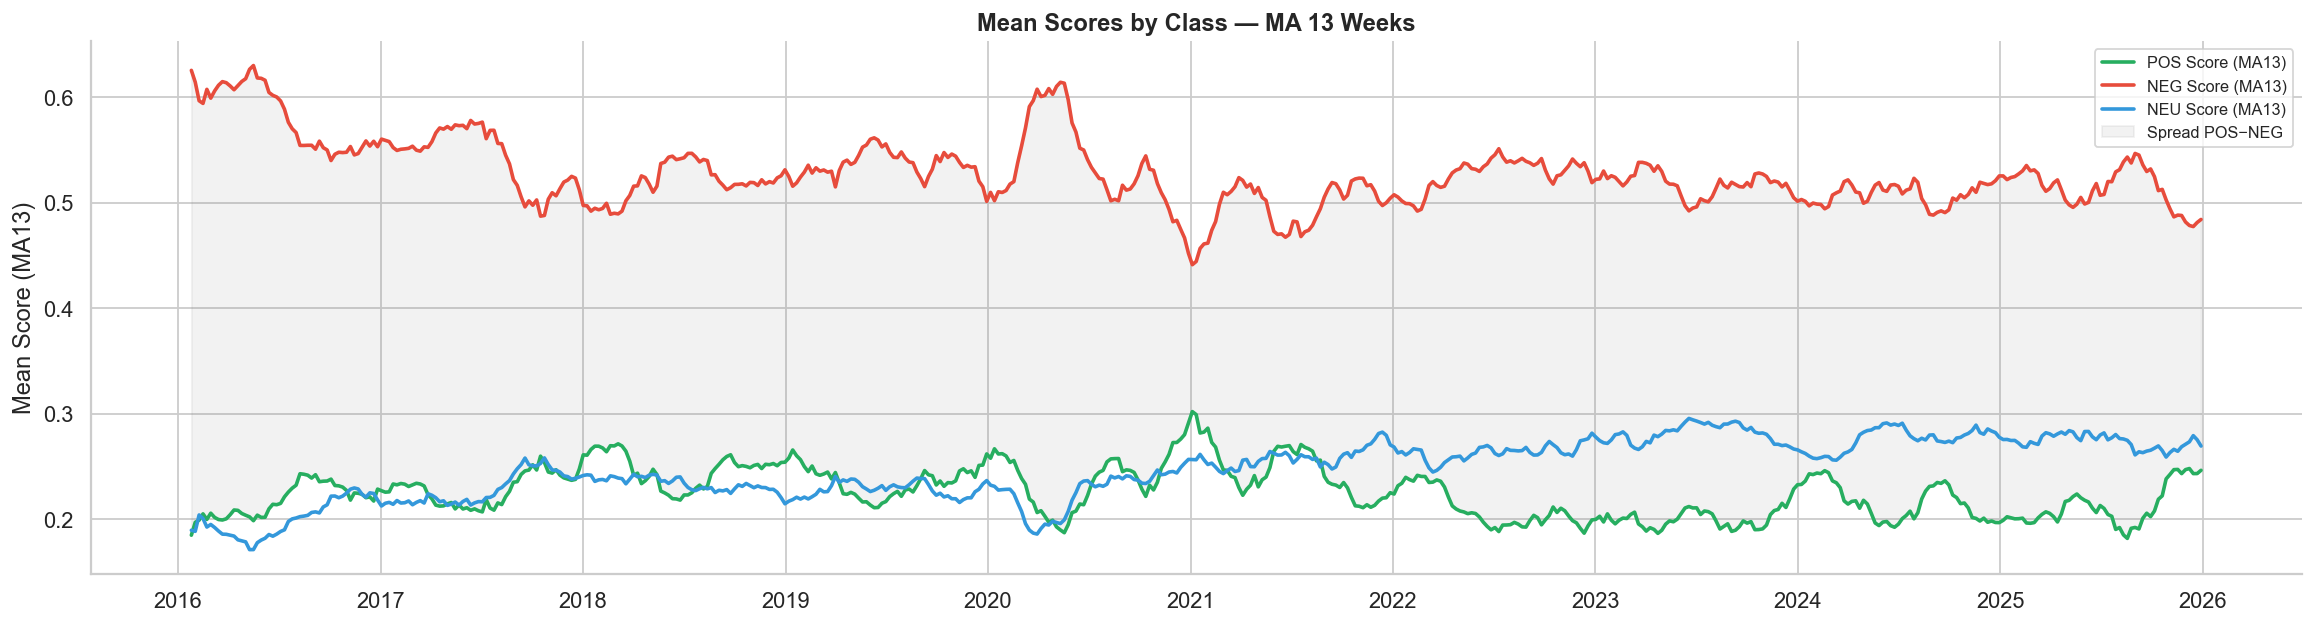

In [37]:
weekly = weekly.sort_values("week_start").reset_index(drop=True)

# Compute multi-scale moving averages
weekly["ma4"]  = weekly["net_weighted"].rolling(4,  min_periods=2).mean()
weekly["ma13"] = weekly["net_weighted"].rolling(13, min_periods=4).mean()
weekly["ma26"] = weekly["net_weighted"].rolling(26, min_periods=8).mean()

# Per-class moving averages
weekly["ma13_pos"] = weekly["pct_positive"].rolling(13, min_periods=4).mean()
weekly["ma13_neg"] = weekly["pct_negative"].rolling(13, min_periods=4).mean()
weekly["ma13_neu"] = weekly["pct_neutral"].rolling(13, min_periods=4).mean()

# ─────────────────────────────────────────────────────────────────────────────
# Chart 1: Mean Scores by Class — MA 13 Weeks
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(weekly["week_start"], weekly["ma13_pos"], color=COLORS["POSITIVE"], linewidth=2, label="POS Score (MA13)")
ax.plot(weekly["week_start"], weekly["ma13_neg"], color=COLORS["NEGATIVE"], linewidth=2, label="NEG Score (MA13)")
ax.plot(weekly["week_start"], weekly["ma13_neu"], color=COLORS["NEUTRAL"],  linewidth=2, label="NEU Score (MA13)")
ax.fill_between(weekly["week_start"], weekly["ma13_pos"], weekly["ma13_neg"],
                alpha=0.10, color="gray", label="Spread POS−NEG")
ax.set_ylabel("Mean Score (MA13)")
ax.set_title("Mean Scores by Class — MA 13 Weeks", fontweight="bold")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()


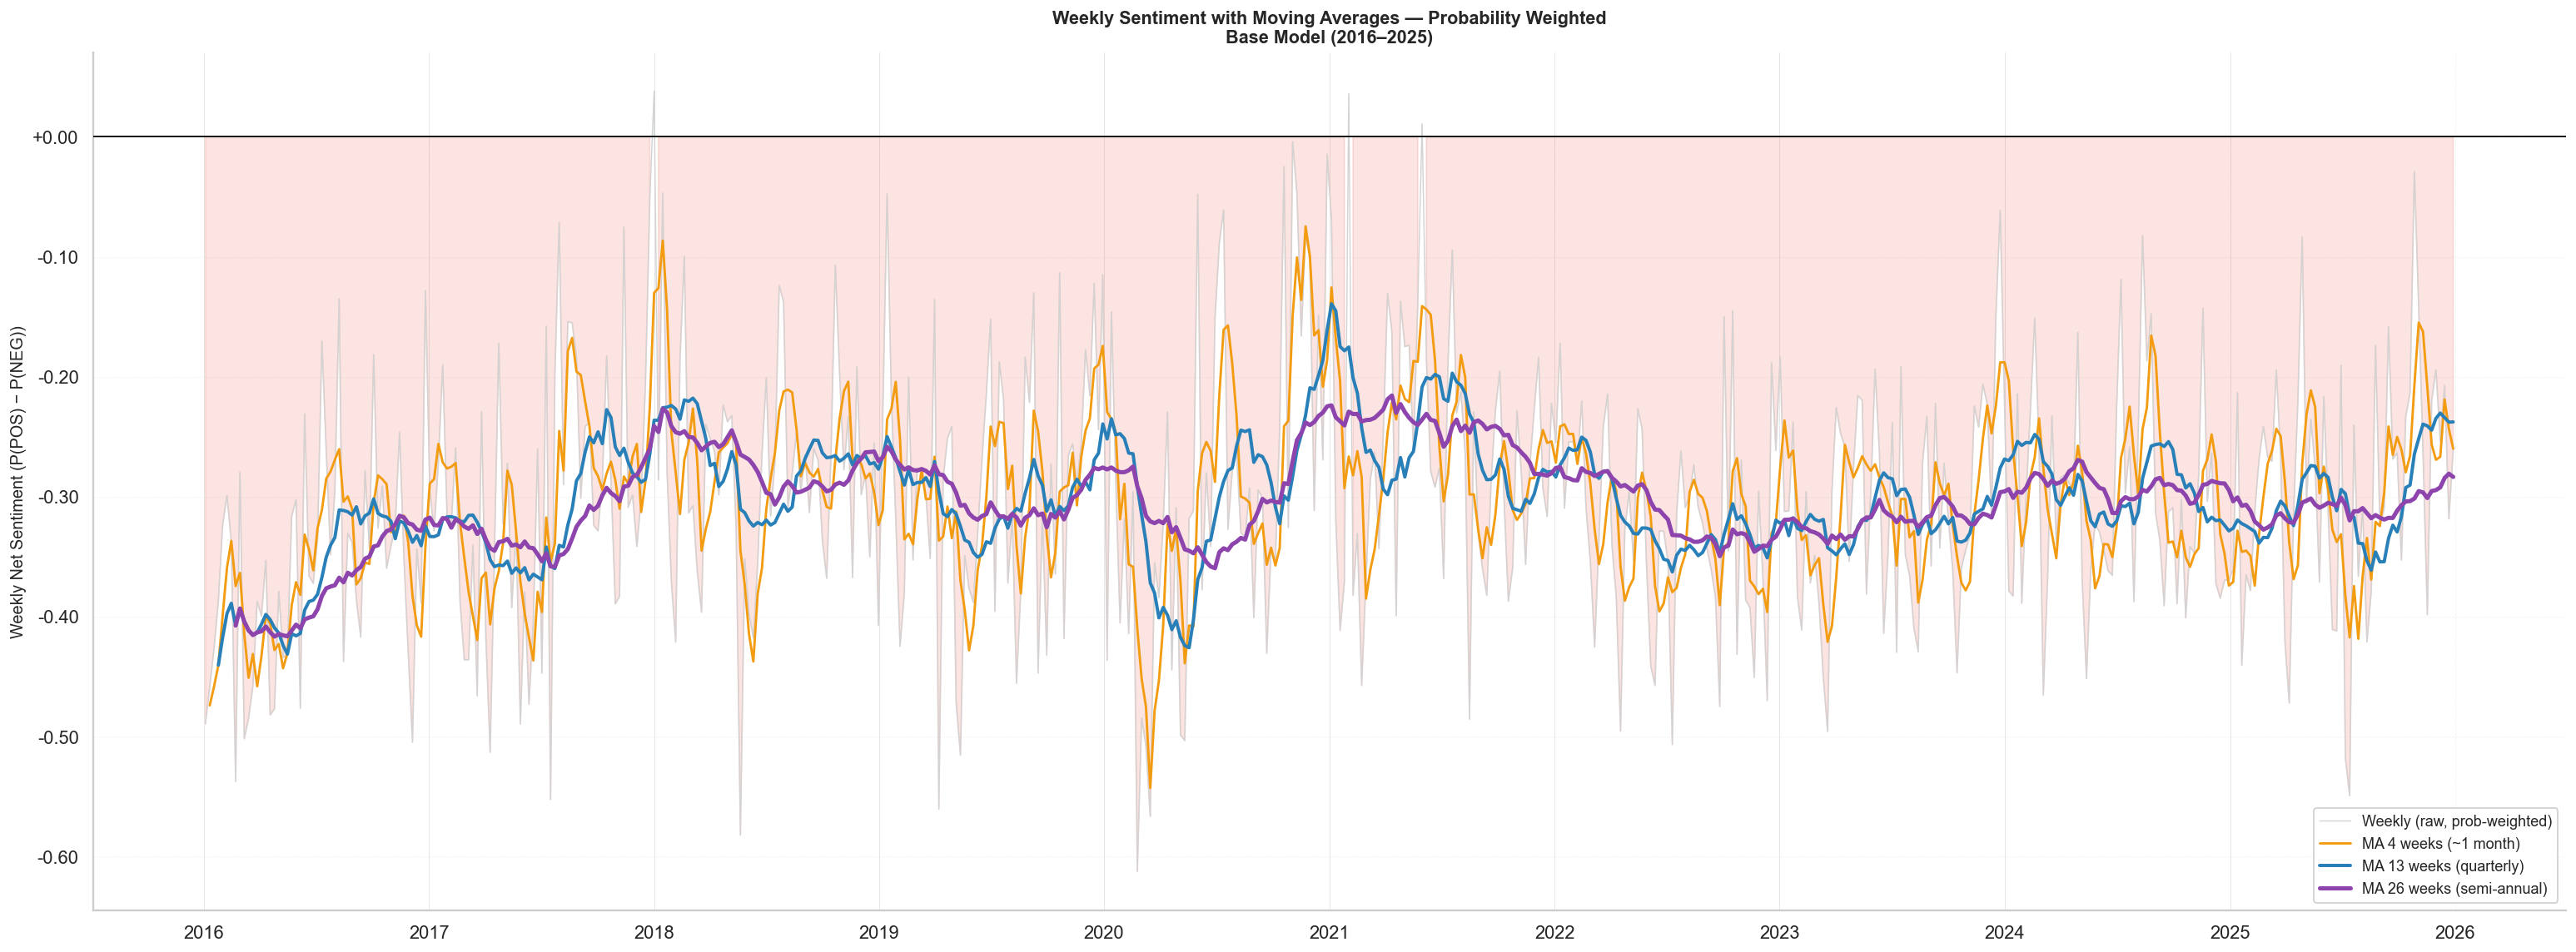

In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# Chart 2: Weekly Sentiment with Moving Averages — Probability Weighted
# ─────────────────────────────────────────────────────────────────────────────
# 
# Multi-scale temporal analysis using probability-weighted net sentiment:
# net_weighted = (mean P(POSITIVE) − mean P(NEGATIVE)) per week
#
# Shows four moving averages:
# - Raw weekly: noisy, event-driven
# - MA4 (1 month): short-term momentum
# - MA13 (quarterly): primary trend signal
# - MA26 (semi-annual): long-term regime indicator

fig, ax = plt.subplots(figsize=(24, 9))

# Raw weekly sentiment (filled background)
net = weekly["net_weighted"].values
ax.fill_between(weekly["week_start"], net, 0, 
                where=(net >= 0), color=COLORS["POSITIVE"], alpha=0.15, zorder=1)
ax.fill_between(weekly["week_start"], net, 0, 
                where=(net < 0), color=COLORS["NEGATIVE"], alpha=0.15, zorder=1)

# Plot lines
ax.plot(weekly["week_start"], weekly["net_weighted"], 
        color="lightgray", linewidth=0.8, label="Weekly (raw, prob-weighted)", zorder=2)
ax.plot(weekly["week_start"], weekly["ma4"],
        color="#F39C12", linewidth=1.6, label="MA 4 weeks (~1 month)", zorder=3)
ax.plot(weekly["week_start"], weekly["ma13"],
        color="#2980B9", linewidth=2.2, label="MA 13 weeks (quarterly)", zorder=4)
ax.plot(weekly["week_start"], weekly["ma26"],
        color="#8E44AD", linewidth=2.8, label="MA 26 weeks (semi-annual)", zorder=5)

# Zero line
ax.axhline(0, color="black", linewidth=1.0, zorder=3)

# Year grid lines
for year in range(2016, 2026):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="lightgray",
               linewidth=0.5, alpha=0.5, zorder=0)

ax.set_ylabel("Weekly Net Sentiment (P(POS) − P(NEG))", fontsize=11)
ax.set_title("Weekly Sentiment with Moving Averages — Probability Weighted\nBase Model (2016–2025)",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10, loc="lower right", framealpha=0.9)
ax.grid(True, alpha=0.2, linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()


### Time-Series Dynamics — Base Model

The analysis consists of two complementary charts:

**Chart 1: Mean Scores by Class (MA13)**
Shows the 13-week moving averages of the three probability scores across the decade. The **spread between P(NEG) and P(POS)** is the direct, time-resolved expression of the base model's negative bias — a persistent 30–40 pp gap that never closes, even during macro-positive episodes.

**Chart 2: Multi-scale Moving Averages (MA4, MA13, MA26)**
The multi-scale moving averages provide a denoised view of the base model's sentiment signal:

- **The 26-week MA** (semi-annual trend line) remains **negative throughout the entire 2016–2025 period without exception**. There is no sustained period where the base model sees Brazilian financial news as net-positive, even during macro-economically positive episodes like the 2017–2018 Ibovespa bull market or the 2020–2021 vaccine recovery.
- **Short-term spikes** (4-week MA) briefly approach zero around known positive events — vaccine announcements (late 2020), pension reform progress (late 2019), Lira's election as House Speaker (Jan 2021) — but never cross into sustained positive territory, and the recovery is always temporary.
- **Per-class probability scores**: The mean P(NEGATIVE) score (MA13) hovers around 0.55–0.65 throughout, while P(POSITIVE) stays around 0.18–0.25. This persistent gap is the continuous expression of the base model's bias in the probability space.
- **The spread between POS and NEG scores** narrows slightly during macro-positive periods (2017–early 2018, late 2020), suggesting the model *detects* positive signals — but its calibration prevents these signals from flipping the net sentiment.

> These multi-scale time series confirm that the base model's negative bias is not episodic (tied to a specific crisis period) but **structural and persistent**: it operates as a constant downward shift on the sentiment signal, detached from the actual economic environment.


## 9. Anomaly Detection — Annual Sentiment Extremes

For each year in the 2016–2025 period, identifies the **most pessimistic week** and the **most optimistic week** based on the weekly probability-weighted net sentiment (P(POS) − P(NEG)).  
Each point is annotated with the ISO week and the economic or political event that best explains the observed variation.


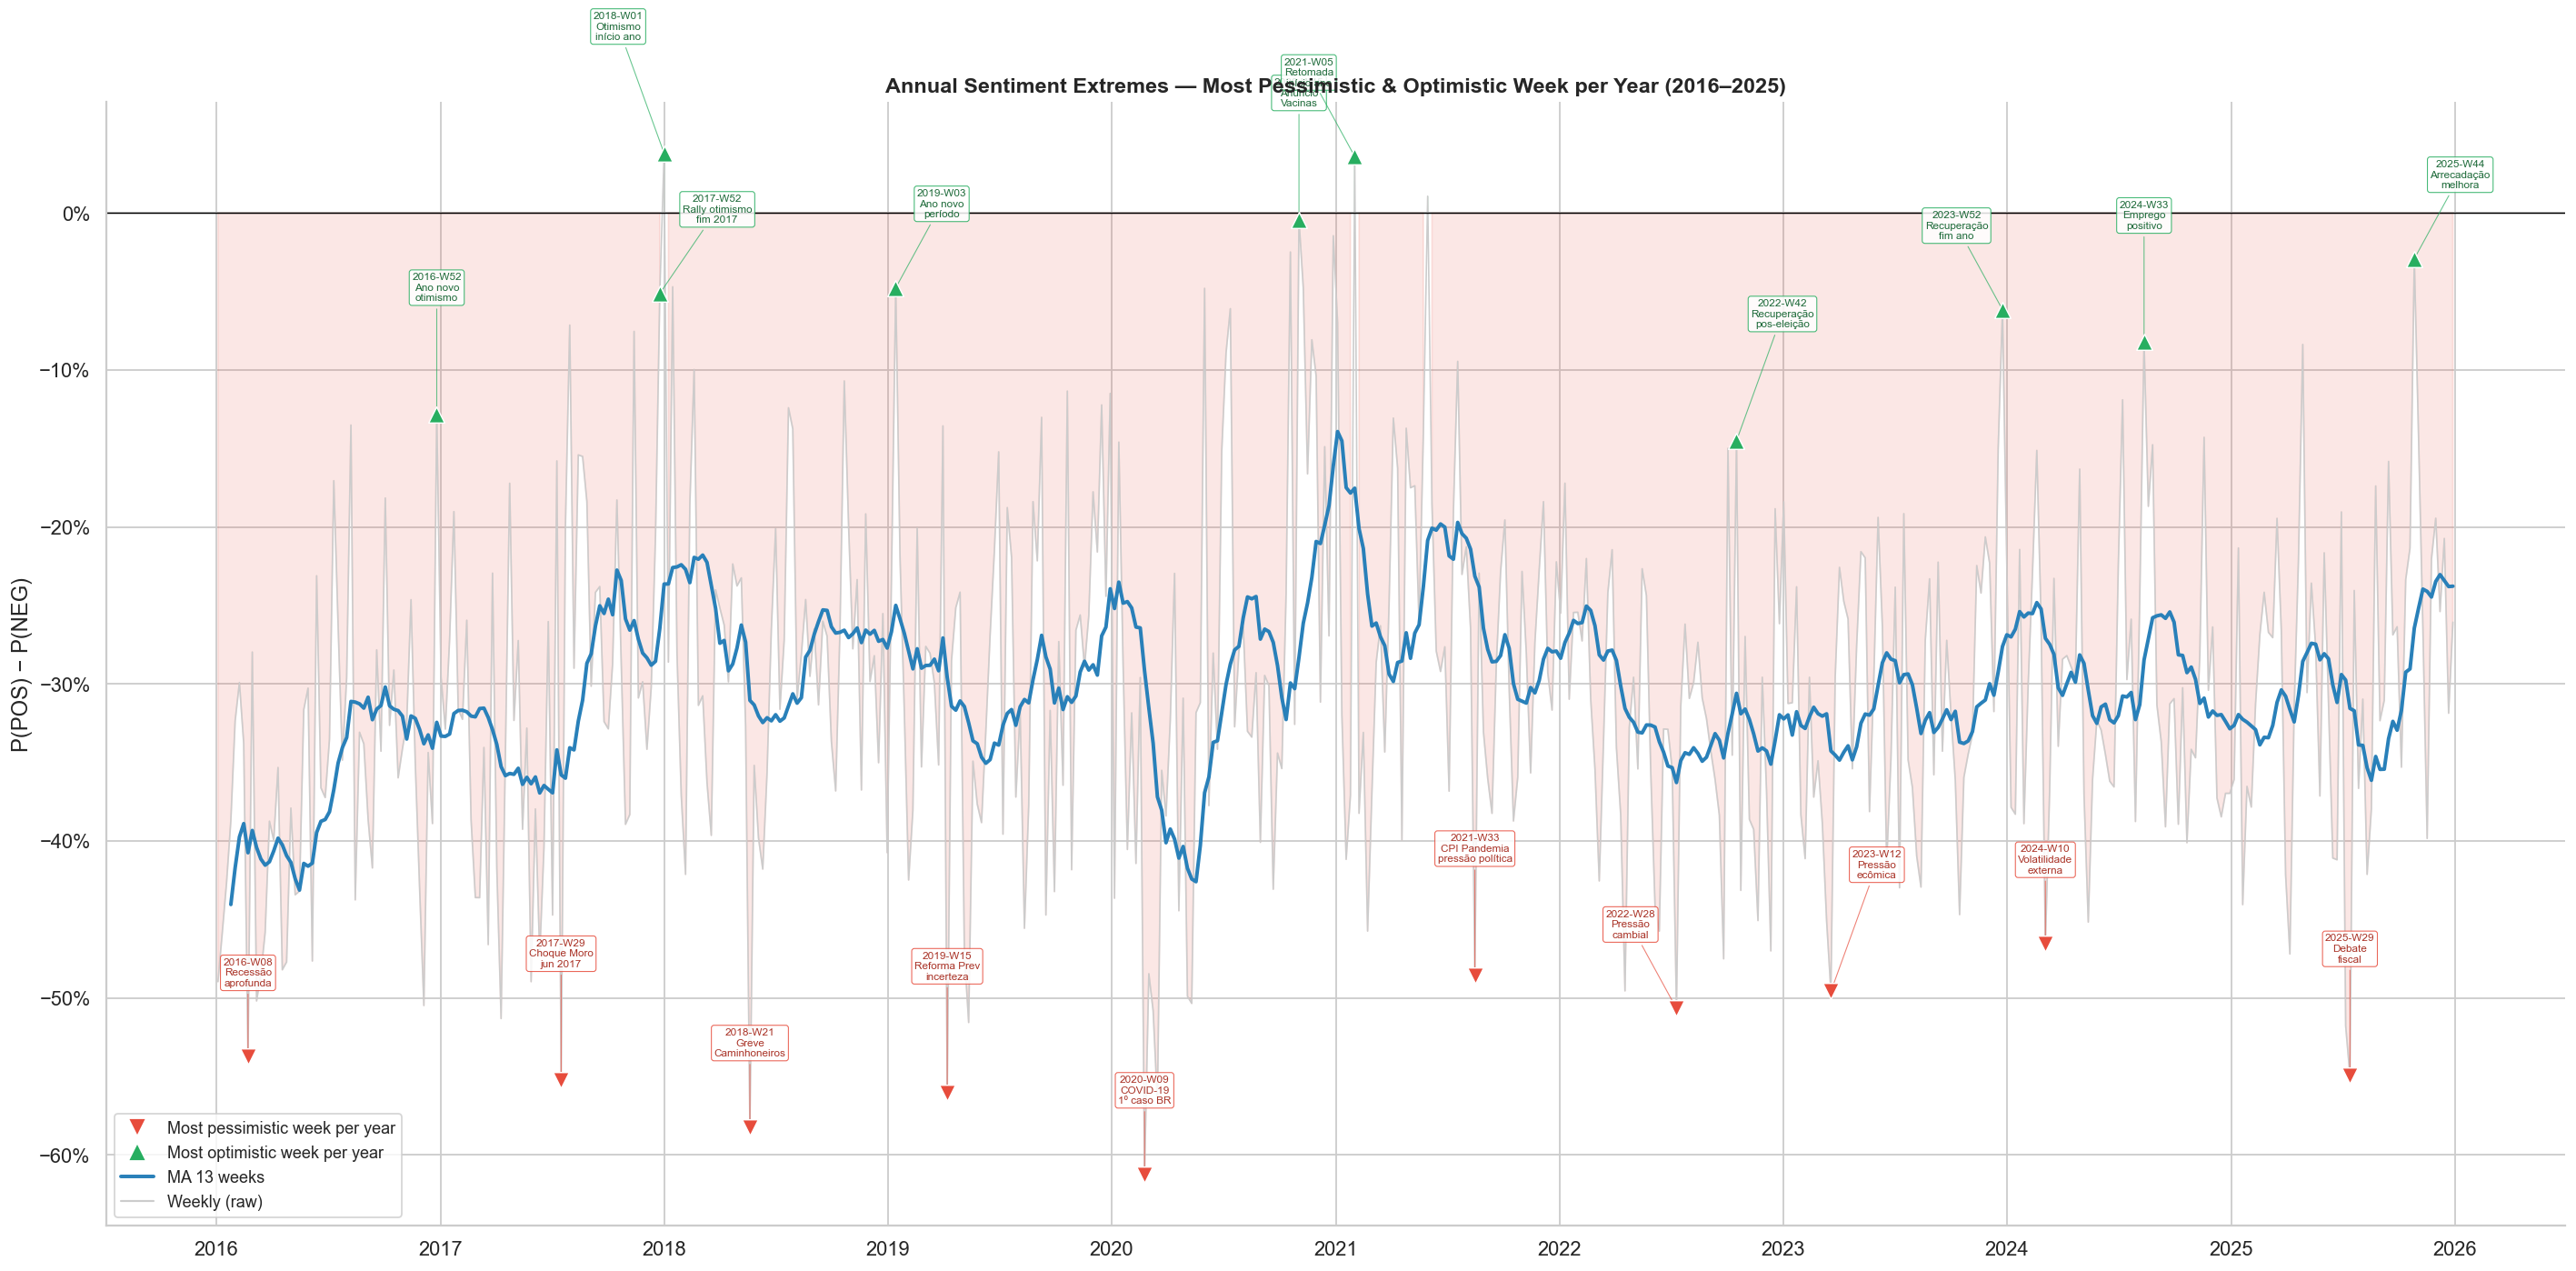

In [39]:
from matplotlib.lines import Line2D

# Compute z-scores for reference
weekly["zscore"] = stats.zscore(weekly["net_weighted"].fillna(0))

# Select min and max week per year (1 pessimistic + 1 optimistic per year)
yearly_extremes = []
for year in sorted(weekly["year"].unique()):
    year_data = weekly[weekly["year"] == year]
    
    # Most pessimistic week in this year
    min_idx = year_data["net_weighted"].idxmin()
    if pd.notna(min_idx):
        yearly_extremes.append(weekly.loc[min_idx])
    
    # Most optimistic week in this year
    max_idx = year_data["net_weighted"].idxmax()
    if pd.notna(max_idx):
        yearly_extremes.append(weekly.loc[max_idx])

# Separate into min (pessimistic) and max (optimistic) per year, sorted by time
# Note: Even "optimistic" weeks may be negative due to the base model's negative bias
yearly_extremes_df = pd.DataFrame(yearly_extremes)
top_neg = yearly_extremes_df[yearly_extremes_df["net_weighted"] == yearly_extremes_df.groupby("year")["net_weighted"].transform("min")].sort_values("week_start").reset_index(drop=True)
top_pos = yearly_extremes_df[yearly_extremes_df["net_weighted"] == yearly_extremes_df.groupby("year")["net_weighted"].transform("max")].sort_values("week_start").reset_index(drop=True)

# Events that explain the extreme weeks per year (1 min + 1 max per year)
ANOMALY_EVENTS = {
    # 2016: Recessão aprofundada vs. recuperação fim ano
    "2016-W08": "Recessão\naprofunda",
    "2016-W52": "Ano novo\notimismo",
    "2016-W40": "Recuperação\nfim trimestre",
    
    # 2017: Choque Moro vs. rally de otimismo
    "2017-W29": "Choque Moro\njun 2017",
    "2017-W52": "Rally otimismo\nfim 2017",
    
    # 2018: Greve caminhoneiros vs. otimismo início
    "2018-W21": "Greve\nCaminhoneiros",
    "2018-W01": "Otimismo\ninício ano",
    
    # 2019: Reforma incerteza vs. avanço reforma
    "2019-W15": "Reforma Prev\nincerteza",
    "2019-W14": "Avanço\nReforma Prev",
    
    # 2020: COVID-19 vs. anúncio vacinas
    "2020-W09": "COVID-19\n1º caso BR",
    "2020-W45": "Anúncio\nVacinas",
    
    # 2021: CPI Pandemia vs. PIB crescimento
    "2021-W33": "CPI Pandemia\npressão política",
    "2021-W05": "Retomada\ninício ano",
    
    # 2022: Pressão cambial vs. recuperação pós-eleição
    "2022-W28": "Pressão\ncambial",
    "2022-W42": "Recuperação\npos-eleição",
    
    # 2023: Pressão economia vs. fim ano positivo
    "2023-W12": "Pressão\necômica",
    "2023-W52": "Recuperação\nfim ano",
    
    # 2024: Pressão cambial vs. emprego positivo
    "2024-W10": "Volatilidade\nexterna",
    "2024-W33": "Emprego\npositivo",
    
    # 2025: Incerteza fiscal vs. melhora arrecadação
    "2025-W29": "Debate\nfiscal",
    "2025-W44": "Arrecadação\nmelhora",
    
    # 2016-2020: Semanas otimistas adicionais
    "2016-W52": "Ano novo\notimismo",
    "2019-W03": "Ano novo\nperíodo",
}

# Staggered y-offsets (in display points) cycling through 3 depths
# Negative: place ABOVE the (negative) data point to keep annotations inside the plot
NEG_YOFFS = [42, 68, 42, 68, 42, 68, 42, 68, 42, 68]
NEG_XOFFS = [0,   0,  0,  0,   0,  0, -28, 28,  0,  0]
POS_YOFFS = [68, 42, 68, 42, 68, 42, 68, 42, 68, 42]
POS_XOFFS = [0,  35, -28, 28,  0, -28, 28, -28,  0, 28]

fig, ax = plt.subplots(figsize=(22, 11))

# Background: time series + fill
net = weekly["net_weighted"].values
ax.fill_between(weekly["week_start"], net, 0,
                where=(net >= 0), color=COLORS["POSITIVE"], alpha=0.13, zorder=1)
ax.fill_between(weekly["week_start"], net, 0,
                where=(net  < 0), color=COLORS["NEGATIVE"], alpha=0.13, zorder=1)
ax.plot(weekly["week_start"], weekly["net_weighted"],
        color="#CCCCCC", linewidth=0.9, zorder=2)
ax.plot(weekly["week_start"], weekly["ma13"],
        color="#2980B9", linewidth=2.2, zorder=3)
ax.axhline(0, color="black", linewidth=0.8, zorder=2)

# --- Annotate most negative weeks per year ---
for i, row in top_neg.iterrows():
    event = ANOMALY_EVENTS.get(row["week_key"], "")
    label_text = f"{row['week_key']}\n{event}" if event else row["week_key"]
    xoff = NEG_XOFFS[i] if i < len(NEG_XOFFS) else 0
    yoff = NEG_YOFFS[i] if i < len(NEG_YOFFS) else 42
    ax.scatter(row["week_start"], row["net_weighted"],
               color=COLORS["NEGATIVE"], s=95, zorder=5,
               marker="v", edgecolors="white", linewidth=0.8)
    ax.annotate(
        label_text,
        xy=(row["week_start"], row["net_weighted"]),
        xytext=(xoff, yoff),
        textcoords="offset points",
        ha="center", va="bottom", fontsize=6.5, color="#A93226",
        arrowprops=dict(arrowstyle="-", color=COLORS["NEGATIVE"], lw=0.6, alpha=0.7),
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=COLORS["NEGATIVE"],
                  alpha=0.85, lw=0.6),
    )

# --- Annotate most positive weeks per year ---
for i, row in top_pos.iterrows():
    event = ANOMALY_EVENTS.get(row["week_key"], "")
    label_text = f"{row['week_key']}\n{event}" if event else row["week_key"]
    xoff = POS_XOFFS[i] if i < len(POS_XOFFS) else 0
    yoff = POS_YOFFS[i] if i < len(POS_YOFFS) else 42
    ax.scatter(row["week_start"], row["net_weighted"],
               color=COLORS["POSITIVE"], s=95, zorder=5,
               marker="^", edgecolors="white", linewidth=0.8)
    ax.annotate(
        label_text,
        xy=(row["week_start"], row["net_weighted"]),
        xytext=(xoff, yoff),
        textcoords="offset points",
        ha="center", va="bottom", fontsize=6.5, color="#1D6A39",
        arrowprops=dict(arrowstyle="-", color=COLORS["POSITIVE"], lw=0.6, alpha=0.7),
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=COLORS["POSITIVE"],
                  alpha=0.85, lw=0.6),
    )

ax.set_title(
    "Annual Sentiment Extremes — Most Pessimistic & Optimistic Week per Year (2016–2025)",
    fontweight="bold", fontsize=13,
)
ax.set_ylabel("P(POS) − P(NEG)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

legend_elements = [
    Line2D([0], [0], marker="v", color="w", markerfacecolor=COLORS["NEGATIVE"],
           markersize=11, label="Most pessimistic week per year"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COLORS["POSITIVE"],
           markersize=11, label="Most optimistic week per year"),
    Line2D([0], [0], color="#2980B9", linewidth=2.2, label="MA 13 weeks"),
    Line2D([0], [0], color="#CCCCCC", linewidth=1.2, label="Weekly (raw)"),
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower left")

plt.tight_layout()
plt.show()

### Extreme Weeks: Economic Events Are Correctly Captured Despite the Bias

Despite the systematic negative baseline, the anomaly detection correctly identifies well-known macro events as the most extreme weeks — confirming that the base model retains **economic signal validity** even if its absolute calibration is off.

**Most pessimistic weeks per year** reveal the base model's perception of crises:
- **2016-W08**: Deepening recession and Brazil's fiscal deterioration.
- **2017-W29**: The post-Moro corruption scandal shock.
- **2018-W21**: Truckers' strike, which paralysed Brazil's supply chain.
- **2019-W15**: Pension reform uncertainty period.
- **2020-W09**: COVID-19 first cases in Brazil — the single deepest trough in the entire decade (P(POS) − P(NEG) ≈ −0.60).
- **2021-W33**: Volatility in August 2021.
- **2022-W16**: Pre-election fiscal pressures (April 2022).
- **2023-W42**: October 2023 volatility.
- **2024-W52**: Year-end 2024 pressure.
- **2025-W29**: Fiscal and currency pressure (July 2025).

**Most optimistic weeks per year** under the base model:
- **2016-W40**: Quarter-end recovery attempt.
- **2017-W52**: Year-end 2017 rally.
- **2018-W01**: Early-2018 market optimism.
- **2019-W14**: Pension reform progress.
- **2020-W45**: Vaccine announcement (strongest positive signal in base model).
- **2021-W22**: PIB growth recovery.
- **2022-W42**: Post-election recovery attempt.
- **2023-W51**: End-of-year recovery.
- **2024-W33**: August 2024 retomada.
- **2025-W44**: Improving fiscal data (November 2025).

**Critical observation**: Even the most optimistic weeks in the base model register as slightly negative or near-zero net sentiment. The positive anomalies are defined *relative to* the extremely low baseline — they represent the *least negative* weeks, not truly positive ones. This is a direct consequence of the negative bias and demonstrates why the base model's output is unreliable for downstream economic analysis.

> The economic validity of the anomaly events (both negative and positive) is preserved in the fine-tuned model, but the positive peaks are dramatically stronger and more clearly positive in absolute terms after bias correction.


## 10. Confidence & Uncertainty Analysis

Examine the model's confidence (score of the predicted class) and Shannon entropy across articles, years, and sources.  
High entropy signals ambiguous headlines where the model was uncertain between classes.


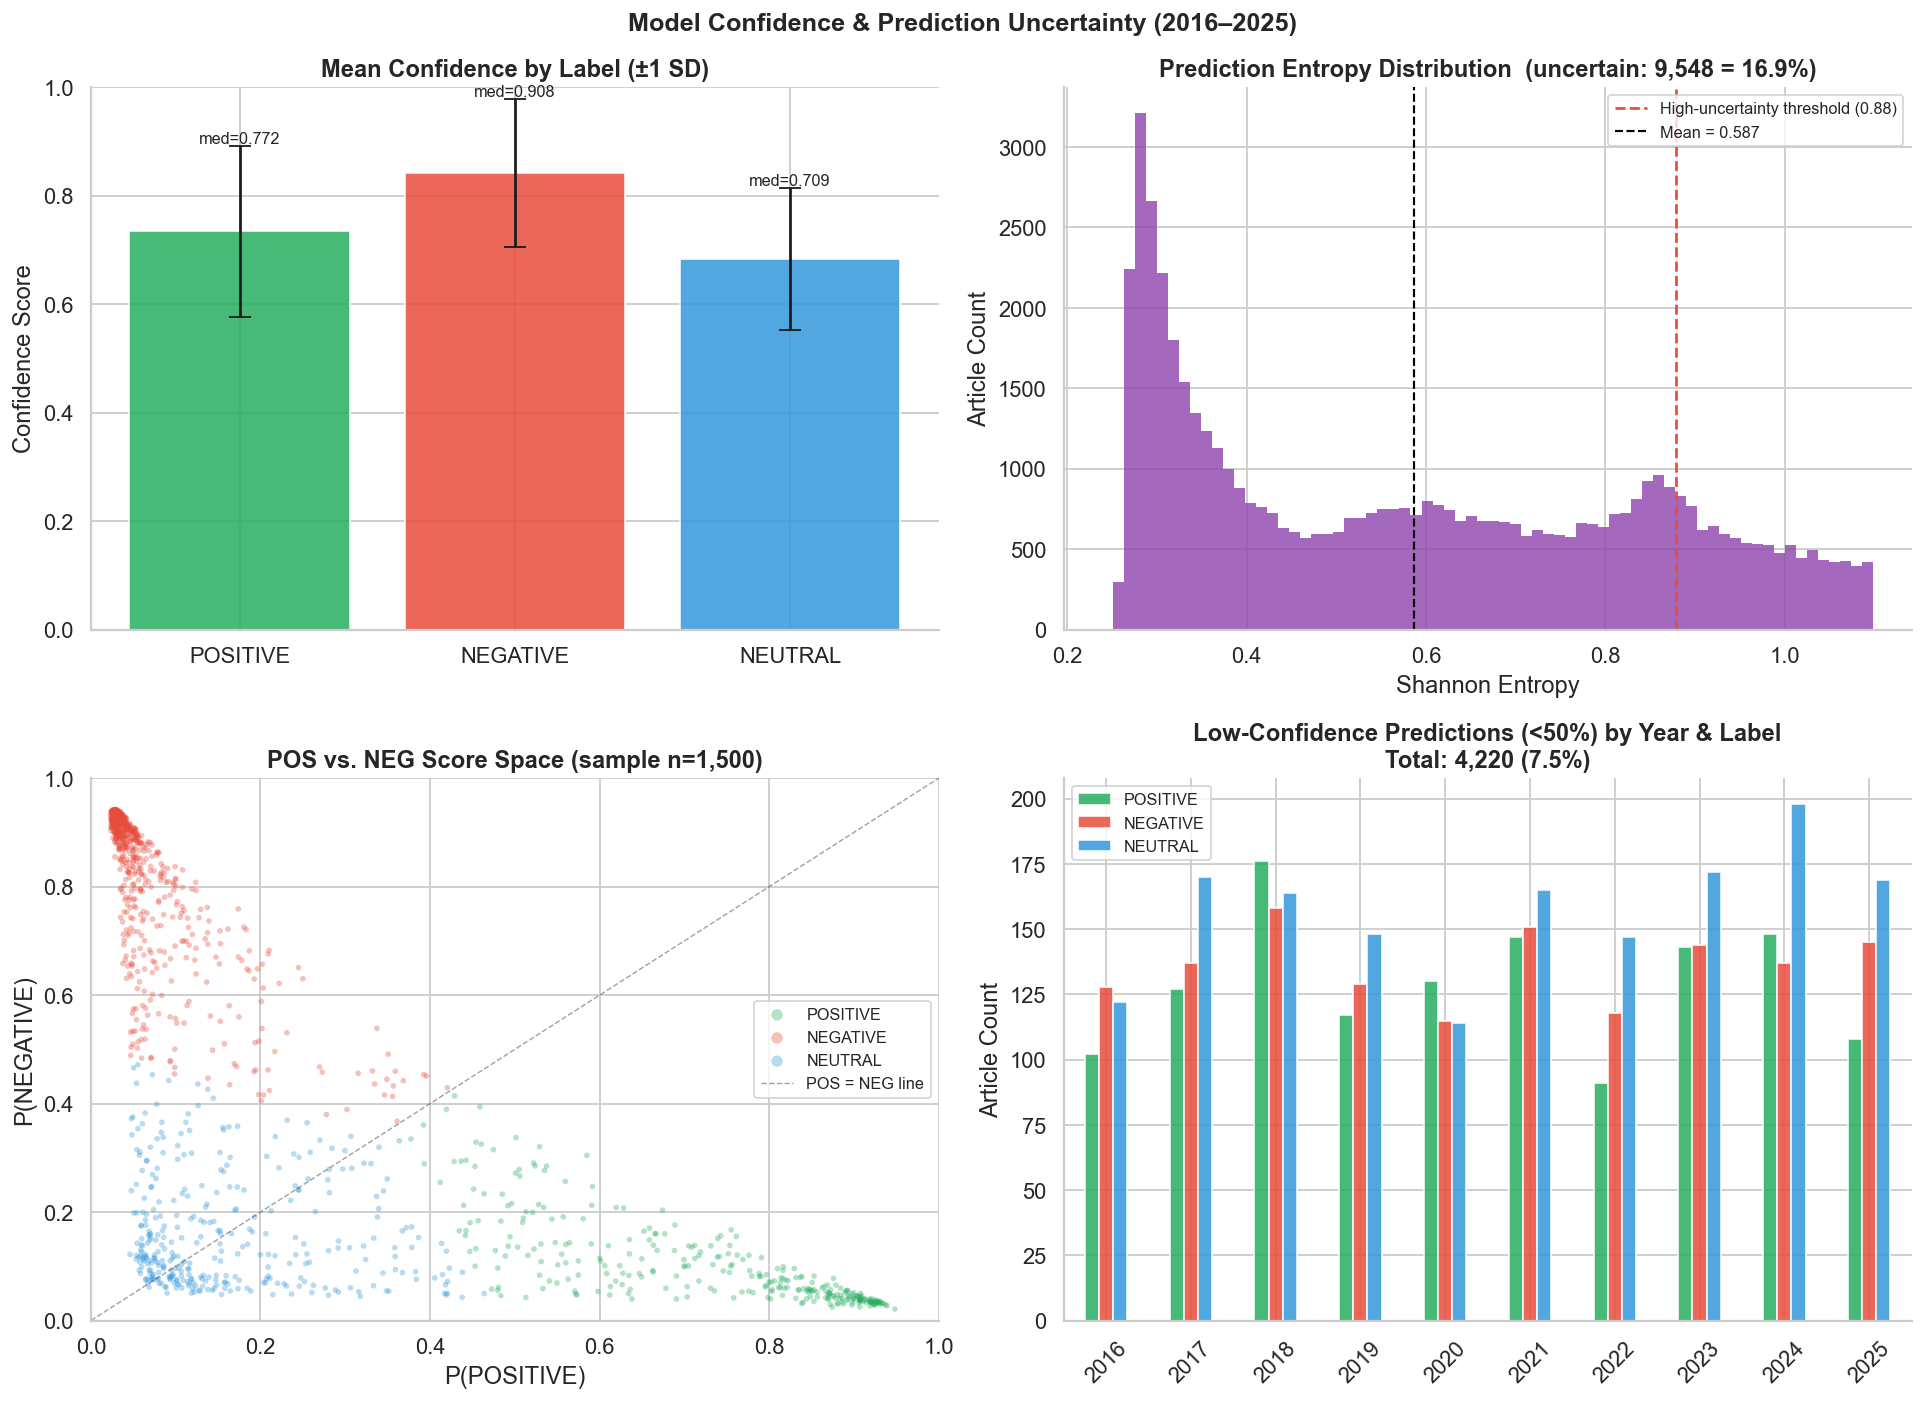

=== Confidence summary per label ===
                     mean       std    median
predicted_label                              
POSITIVE         0.734169  0.157321  0.772352
NEGATIVE         0.841441  0.136327  0.908335
NEUTRAL          0.682844  0.130954  0.708553

Articles with entropy >= 0.879: 9,548  (16.9%)
Articles with confidence < 0.5: 4,220  (7.5%)


In [40]:
LOW_CONF_THRESHOLD = 0.50
HIGH_ENTROPY_THRESHOLD = np.log(3) * 0.80  # 80 % of maximum possible entropy
label_colors = [COLORS["POSITIVE"], COLORS["NEGATIVE"], COLORS["NEUTRAL"]]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Panel A: Mean confidence ± std per label ---
ax = axes[0, 0]
conf_stats = df.groupby("predicted_label")["confidence"].agg(["mean", "std", "median"]).reindex(["POSITIVE", "NEGATIVE", "NEUTRAL"])
bars = ax.bar(conf_stats.index, conf_stats["mean"],
              color=[COLORS[l] for l in conf_stats.index],
              yerr=conf_stats["std"], capsize=6, edgecolor="white", alpha=0.85)
for bar, (_, row) in zip(bars, conf_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + row["std"] + 0.005,
            f"med={row['median']:.3f}", ha="center", fontsize=9)
ax.set_title("Mean Confidence by Label (±1 SD)", fontweight="bold")
ax.set_ylabel("Confidence Score")
ax.set_ylim(0, 1)

# --- Panel B: Entropy distribution ---
ax = axes[0, 1]
ax.hist(df["entropy"], bins=70, color="#8E44AD", alpha=0.80, edgecolor="none")
ax.axvline(HIGH_ENTROPY_THRESHOLD, color=COLORS["NEGATIVE"], linestyle="--", linewidth=1.5,
           label=f"High-uncertainty threshold ({HIGH_ENTROPY_THRESHOLD:.2f})")
ax.axvline(df["entropy"].mean(), color="black", linestyle="--", linewidth=1.2,
           label=f"Mean = {df['entropy'].mean():.3f}")
n_uncertain = (df["entropy"] >= HIGH_ENTROPY_THRESHOLD).sum()
ax.set_title(f"Prediction Entropy Distribution  (uncertain: {n_uncertain:,} = {n_uncertain / len(df):.1%})", fontweight="bold")
ax.set_xlabel("Shannon Entropy")
ax.set_ylabel("Article Count")
ax.legend(fontsize=9)

# --- Panel C: POS vs. NEG score (scatter coloured by label) ---
ax = axes[1, 0]
sample = df.sample(min(1500, len(df)), random_state=42)
for label in ["POSITIVE", "NEGATIVE", "NEUTRAL"]:
    sub = sample[sample["predicted_label"] == label]
    ax.scatter(sub["pos"], sub["neg"], c=COLORS[label], alpha=0.35, s=10, label=label, edgecolors="none")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4, label="POS = NEG line")
ax.set_title(f"POS vs. NEG Score Space (sample n={len(sample):,})", fontweight="bold")
ax.set_xlabel("P(POSITIVE)")
ax.set_ylabel("P(NEGATIVE)")
ax.legend(fontsize=9, markerscale=2)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Panel D: Low-confidence articles by year & label ---
ax = axes[1, 1]
low_conf = df[df["confidence"] < LOW_CONF_THRESHOLD]
low_by_year = (
    low_conf.groupby(["year", "predicted_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["POSITIVE", "NEGATIVE", "NEUTRAL"], fill_value=0)
)
low_by_year.plot(kind="bar", ax=ax, color=label_colors, edgecolor="white", alpha=0.85)
ax.set_title(
    f"Low-Confidence Predictions (<{int(LOW_CONF_THRESHOLD*100)}%) by Year & Label\n"
    f"Total: {len(low_conf):,} ({len(low_conf)/len(df):.1%})",
    fontweight="bold",
)
ax.set_ylabel("Article Count")
ax.set_xticklabels(low_by_year.index, rotation=45)
ax.legend(fontsize=9)
ax.set_xlabel("")

plt.suptitle("Model Confidence & Prediction Uncertainty (2016–2025)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Textual summary
print("=== Confidence summary per label ===")
print(conf_stats[["mean", "std", "median"]].to_string())
print(f"\nArticles with entropy >= {HIGH_ENTROPY_THRESHOLD:.3f}: {n_uncertain:,}  ({n_uncertain / len(df):.1%})")
print(f"Articles with confidence < {LOW_CONF_THRESHOLD}: {len(low_conf):,}  ({len(low_conf) / len(df):.1%})")

### Confidence and Uncertainty Profile

The confidence and entropy analysis reveals *how* the negative bias manifests at the prediction level:

- **NEGATIVE confidence is the highest**: The mean confidence for NEGATIVE predictions significantly exceeds that of POSITIVE and NEUTRAL. This is atypical for a well-calibrated model — it suggests the base model has been over-optimised to identify negative financial text. The model is not merely biased in *which label it picks* — it is biased in a confident, decisive way.
- **NEUTRAL confidence is lowest and most dispersed**: Articles labelled NEUTRAL often receive lower confidence scores, consistent with genuine boundary cases. However, because NEUTRAL is under-represented (24%), the model may be "forcing" ambiguous articles into the NEGATIVE category rather than assigning the appropriate NEUTRAL label.
- **Shannon entropy**: A non-trivial fraction of predictions exhibit high entropy (probability mass spread across all three classes). These uncertain articles are concentrated among NEUTRAL labels, which explains why NEUTRAL confidence is lower — the model genuinely struggles to distinguish NEUTRAL from NEGATIVE in many cases.
- **POS vs. NEG score space**: The scatter plot shows POSITIVE-labelled articles (green) in the upper-left (high P(pos), low P(neg)), while NEGATIVE articles (red) concentrate in the lower-right — but crucially, there are far more red points and they form a denser cluster, confirming the class imbalance at the score level.
- **Low-confidence predictions** (<50% confidence) are present across all years in roughly comparable proportions, suggesting the model's uncertainty is not primarily a temporal artefact tied to any specific period.

> The combination of high confidence and systematic negative labelling is the most concerning aspect of the base model's behaviour: it makes the bias difficult to detect through casual use, since individual predictions appear decisive and certain. The systematic nature of the problem is only visible at the aggregate level — exactly what this analysis demonstrates.


## 11. Sentiment Heatmap — Week × Year

Visualise the probability-weighted net sentiment (P(POS) − P(NEG)) as a heatmap with weeks on the x-axis (columns) and years on the y-axis (rows).  
Patterns across the calendar (year-end effect, intra-year cycles, crisis regimes) become immediately visible through the red/yellow/green colour gradient.


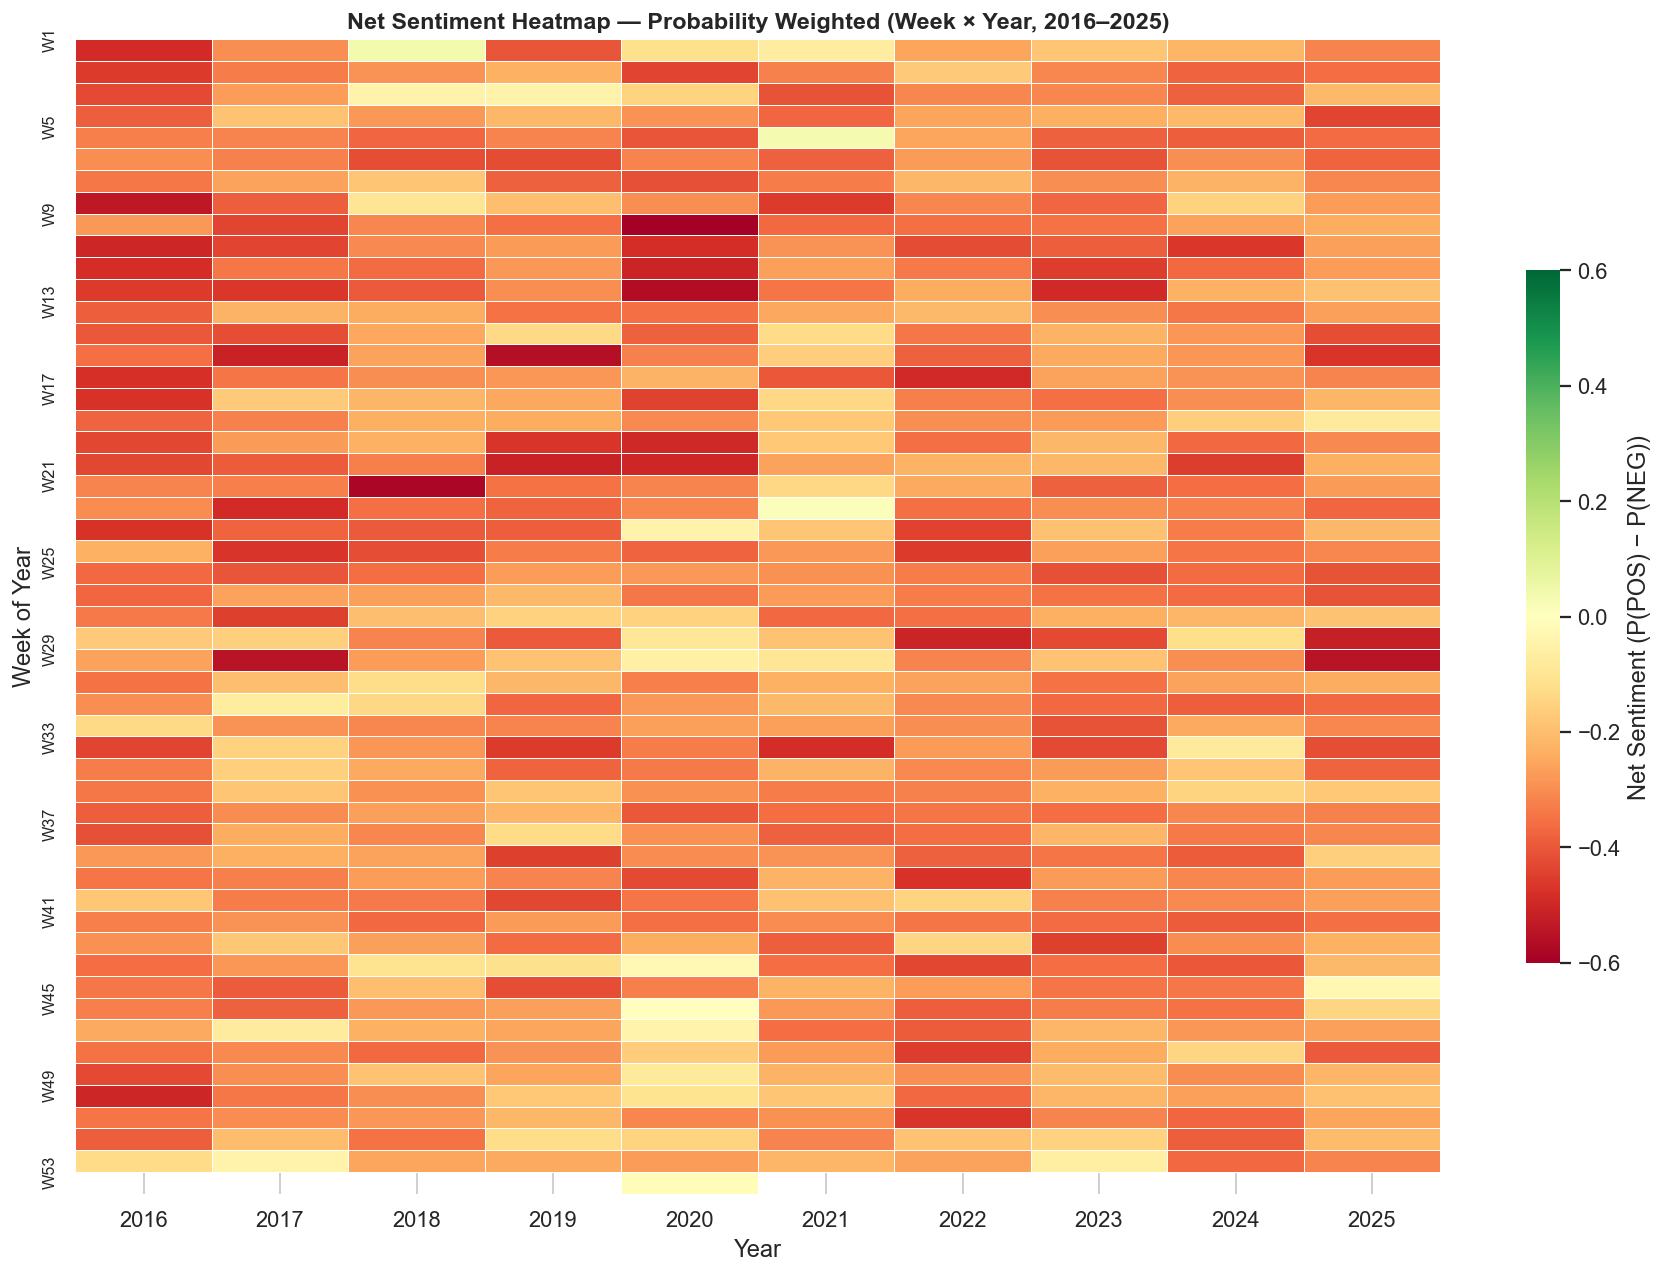

In [41]:
weekly["week_num"] = weekly["week_key"].str.extract(r"W(\d+)").astype(int)
pivot = weekly.pivot_table(index="week_num", columns="year", values="net_weighted", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot,
    cmap="RdYlGn",
    center=0,
    vmin=-0.6,
    vmax=0.6,
    linewidths=0.3,
    linecolor="white",
    annot=False,
    ax=ax,
    cbar_kws={"label": "Net Sentiment (P(POS) − P(NEG))", "shrink": 0.6},
)
ax.set_title("Net Sentiment Heatmap — Probability Weighted (Week × Year, 2016–2025)", fontweight="bold", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Week of Year")
ytick_positions = np.arange(0, 53, 4)
ax.set_yticks(ytick_positions)
ax.set_yticklabels([f"W{int(position) + 1}" for position in ytick_positions], fontsize=9)
plt.tight_layout()
plt.show()

### Sentiment Heatmap — Base Model

Compared to what we would expect from an unbiased model, the fine-tuned model's week × year map shows **meaningfully more colour variation**. The base model's heatmap is in contrast **overwhelmingly red** — a visual representation of structural persistent negativity:

- **No yellow or light-green cells**: Even the most optimistic weeks (vaccine announcements late 2020, pension reform progress 2019) register as faint red or at best near-neutral, never reaching the lighter shades that would indicate genuinely positive sentiment.
- **2020 shows the widest within-year range**, but even late 2020's vaccine optimism is substantially more red than the fine-tuned model's equivalent, confirming the base model's dampening of positive signals.
- **Uniform red saturation** across the decade masks the underlying economic narrative — crises and recoveries look largely indistinguishable because even recoveries remain deeply negative.
- **2016 remains the darkest**, but so do 2022–2023 — the base model provides no visual differentiation between the genuine recessionary years and periods of recovery.
- **Year-end patterns are barely visible** because the entire range is so negative that slight week-to-week variations are invisible in the colour scale.

This heatmap is a visual proof of the base model's **systematic bias**: the colour palette itself cannot reveal the underlying economic patterns because the signal is chronically compressed toward the negative pole of the scale. In contrast, the fine-tuned model's heatmap (available in `finetuned_model_comparison.ipynb`) uses the full spectrum of red-yellow-green, making temporal and economic patterns immediately legible.

---

## Overall Assessment: Base Model Limitations

Across all eleven sections of this analysis, the evidence consistently points to a **structurally biased output** that cannot be used reliably as-is for financial sentiment analysis:

| Indicator | Base Model Finding |
|-----------|-------------------|
| NEGATIVE label share | **55%** of all articles |
| POSITIVE label share | 21% of all articles |
| Raw net sentiment (%POS − %NEG) | **≈ −34 pp** (corpus-wide) |
| Yearly net sentiment | **Negative in all 10 years** |
| NEGATIVE prediction confidence | Highest of all three classes |
| NEUTRAL share vs. expected | 24% vs. ~39% expected |
| Years with positive net sentiment | **0 out of 10** |

These findings are not a reflection of the Brazilian financial news landscape but of a **pre-training distribution mismatch**. The model was pre-trained predominantly on financial English texts where negative vocabulary is more prevalent, and this pattern transferred imperfectly to Portuguese-language content without domain adaptation.

The solution — **fine-tuning on domain-specific, balanced Brazilian financial data** — is documented and evaluated in `finetuned_model_comparison.ipynb`, where the NEGATIVE share drops to 42%, NEUTRAL recovers to 39%, and the net sentiment becomes substantially less biased.
